# MLP 2

## Intial

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
words = open("names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
len (words)


32034

In [ ]:
char = sorted(list(set(''.join(words))))
stoi = { x:i+1 for i, x in enumerate(char)}
stoi['.'] = 0
itos = {x:i for i,x in stoi.items()}
print(stoi)
itos
vocab_size = len(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [ ]:
block_size = 3



def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182485, 3]) torch.Size([182485])
torch.Size([22822, 3]) torch.Size([22822])
torch.Size([22846, 3]) torch.Size([22846])


In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )
b1 = (torch.rand(n_hidden))
W2 = torch.randn(n_hidden, vocab_size)
b2 = torch.randn(vocab_size)
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [ ]:
max_steps = 50000
batch_Size = 32
lossi = []

In [ ]:

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    h= torch.tanh(emb.view(emb.shape[0], -1) @W1 +b1)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad

    if i%5000 == 0:
        print(f'{i} th/ {max_steps}: {loss}')

0 th/ 50000: 25.560192108154297
5000 th/ 50000: 2.614905834197998
10000 th/ 50000: 2.473719835281372
15000 th/ 50000: 2.9178059101104736
20000 th/ 50000: 1.8898283243179321
25000 th/ 50000: 2.649614095687866
30000 th/ 50000: 2.420649290084839
35000 th/ 50000: 2.4880290031433105
40000 th/ 50000: 2.7458038330078125
45000 th/ 50000: 2.3121418952941895


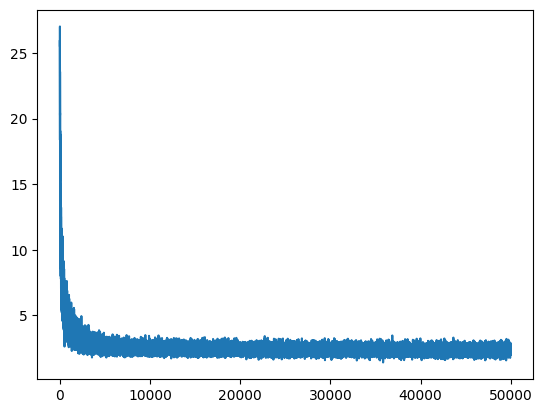

In [ ]:
plt.plot(lossi)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    h1 = torch.tanh(emb.view(emb.shape[0],-1)@W1+b1)
    logits = h1@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.3389)
tensor(2.3554)


In [ ]:
# @torch.no_grad()
g =torch.Generator().manual_seed(7607665605+10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(emb.shape[0], -1) @W1 +b1)
        logits = h@W2 +b2
        prob = torch.softmax(logits,dim = 1)
        # print(prob)
        ix = torch.multinomial(prob,num_samples = 1,generator = g, replacement = True).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix ==0:
            break
    
    print(''.join(out))

myvon.
amyjana.
landoydynn.
nay.
oneswea.
con.
nel.
jeite.
toron.
ekaef.
bian.
buer.
zilor.
feed.
nyja.
tye.
jiof.
niza.
rana.
hina.


## Understanding Intialization

### Improving Logits

In [ ]:
#At intial the probablity for all char that 
# could come should be same that is 1/27
# and that can be almost done via W2 and b2 making it somewhere near to 0 instead of 
#anything random
# In this problem it is intuitive to make like the first character to have same probablity for everything
# and  hence the first loss should be about 3.29 so
#the work can be easily started instead of doing unnecessary updates in first 1000s of iterations.
-torch.tensor(1/27).log()

tensor(3.2958)

In [ ]:
logits = torch.tensor([0.0,0,2,0])
probs = torch.softmax(logits, dim = 0)
loss = -probs[2].log()
probs, loss


(tensor([0.0963, 0.0963, 0.7112, 0.0963]), tensor(0.3408))

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )
b1 = (torch.rand(n_hidden))
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [ ]:
max_steps = 50001
batch_Size = 32
lossi = []

In [ ]:

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad

    # print(i, loss)

0th/ 50001: 4.396481513977051
5000th/ 50001: 2.311508893966675
10000th/ 50001: 1.8639253377914429
15000th/ 50001: 2.225987672805786
20000th/ 50001: 2.379157066345215
25000th/ 50001: 1.989499568939209
30000th/ 50001: 2.8931519985198975
35000th/ 50001: 2.5066001415252686
40000th/ 50001: 2.3183674812316895
45000th/ 50001: 2.196840286254883
50000th/ 50001: 1.9970422983169556


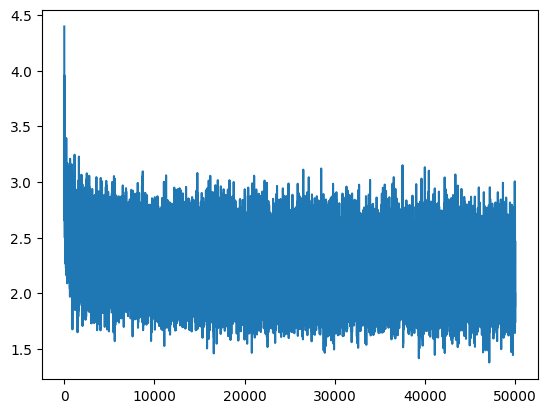

In [ ]:
plt.plot(lossi)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    h1 = torch.tanh(emb.view(emb.shape[0],-1)@W1+b1)
    logits = h1@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.1852)
tensor(2.2366)


### Investigating first hidden layer(hpreact)

torch.Size([32, 200])


(array([2170.,  180.,  129.,   77.,   63.,   39.,   47.,   30.,   32.,
          38.,   22.,   24.,   41.,   36.,   20.,   24.,   42.,   32.,
          37.,   58.,   57.,   78.,  149.,  172., 2803.]),
 array([-1.  , -0.92, -0.84, -0.76, -0.68, -0.6 , -0.52, -0.44, -0.36,
        -0.28, -0.2 , -0.12, -0.04,  0.04,  0.12,  0.2 ,  0.28,  0.36,
         0.44,  0.52,  0.6 ,  0.68,  0.76,  0.84,  0.92,  1.  ]),
 <BarContainer object of 25 artists>)

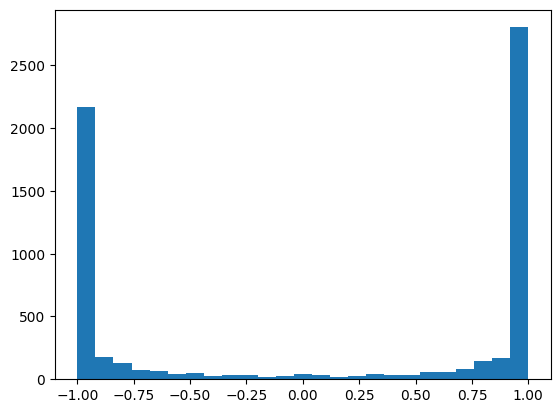

In [ ]:
#THE DEEPER PROBLEM
print(h.shape)
plt.hist(h.view(-1).tolist(),25)
#see the h itself has more numbers on extreme
#BAD NEWS
# Gradients at this layers are destroyed and couldn't
# work properly in this image

(array([  1.,   3.,   3.,   7.,   6.,  14.,  15.,  15.,  34.,  33.,  52.,
         79.,  95.,  96., 131., 142., 177., 226., 225., 273., 259., 328.,
        434., 319., 410., 423., 363., 293., 294., 282., 268., 210., 175.,
        174., 112.,  94.,  79.,  59.,  36.,  32.,  26.,  32.,  32.,  14.,
         14.,   3.,   1.,   5.,   0.,   2.]),
 array([-20.89256477, -20.01094364, -19.12932251, -18.24770138,
        -17.36608025, -16.48445911, -15.60283798, -14.72121685,
        -13.83959572, -12.95797459, -12.07635345, -11.19473232,
        -10.31311119,  -9.43149006,  -8.54986893,  -7.6682478 ,
         -6.78662666,  -5.90500553,  -5.0233844 ,  -4.14176327,
         -3.26014214,  -2.378521  ,  -1.49689987,  -0.61527874,
          0.26634239,   1.14796352,   2.02958466,   2.91120579,
          3.79282692,   4.67444805,   5.55606918,   6.43769032,
          7.31931145,   8.20093258,   9.08255371,   9.96417484,
         10.84579597,  11.72741711,  12.60903824,  13.49065937,
         14.372280

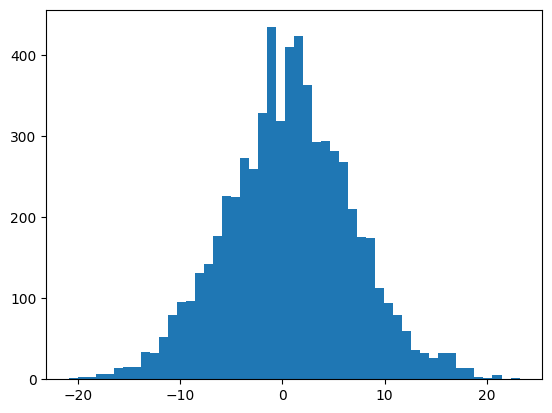

In [ ]:
plt.hist(hpreact.view(-1).tolist(),50) #Before Tanh 
#this is bad coz the value ranges from -20 to 20 which will affect later
# so make it somewhere near zero.

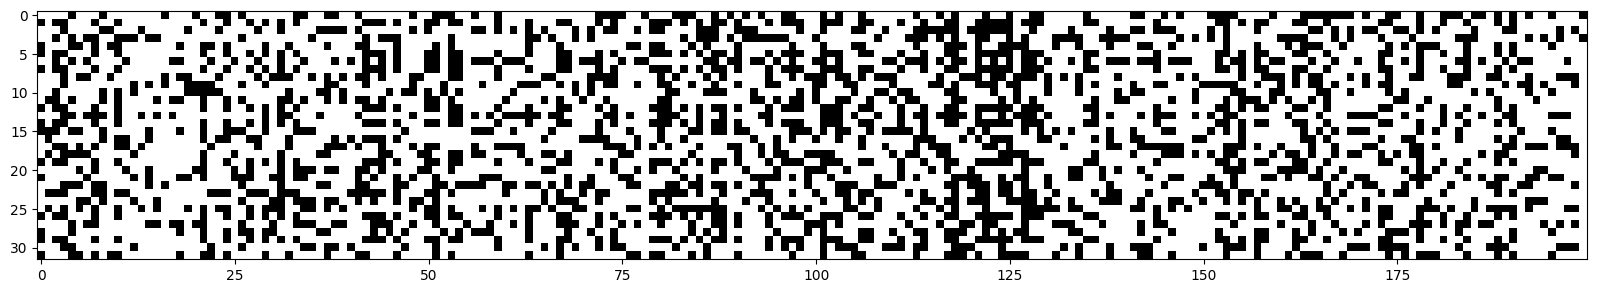

In [ ]:
plt.figure(figsize = (20,10))
plt.imshow(h.abs()> 0.99, cmap = 'gray', interpolation='nearest')
# in h layer WHITE MEANS VERY BAD because it represents 1 and being 1 in tanh 
# it's derivative is (1-t**2) so everything becomes zero for previous passes 
# and things couldn't be learn efficiently
# if in this figure a single column is all white then gradient is totally 
# blocked for preious neurons
# so., tanh itself has issue as a matter of fact most non-linear activation function 
# have this issue like sigmoid, ReLU


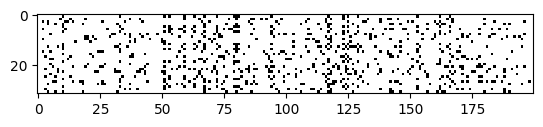

In [ ]:
plt.imshow(hpreact.abs()> 0.99, cmap = 'gray', interpolation='nearest')


In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad


11897
0th/ 50001: 3.5667760372161865
5000th/ 50001: 2.3959169387817383
10000th/ 50001: 1.92703378200531
15000th/ 50001: 2.3845865726470947
20000th/ 50001: 2.0162100791931152
25000th/ 50001: 2.240574598312378
30000th/ 50001: 2.2720158100128174
35000th/ 50001: 2.3268978595733643
40000th/ 50001: 2.065809965133667
45000th/ 50001: 2.014606475830078
50000th/ 50001: 2.120161771774292


In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    h1 = torch.tanh(emb.view(emb.shape[0],-1)@W1+b1)
    logits = h1@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.1551)
tensor(2.2008)


11897
0th/ 50001: 3.4864697456359863


(array([ 16.,  46.,  51.,  58.,  80.,  97., 100., 123., 126., 129., 120.,
        140., 129., 167., 145., 145., 184., 182., 153., 140., 184., 155.,
        182., 171., 199., 164., 159., 170., 181., 192., 139., 161., 180.,
        173., 177., 151., 133., 142., 150., 118., 142., 119.,  93.,  93.,
         91.,  97.,  71.,  45.,  27.,  10.]),
 array([-0.97365206, -0.93456597, -0.89547988, -0.85639379, -0.81730769,
        -0.7782216 , -0.73913551, -0.70004942, -0.66096332, -0.62187723,
        -0.58279114, -0.54370504, -0.50461895, -0.46553286, -0.42644677,
        -0.38736067, -0.34827458, -0.30918849, -0.2701024 , -0.2310163 ,
        -0.19193021, -0.15284412, -0.11375803, -0.07467193, -0.03558584,
         0.00350025,  0.04258635,  0.08167244,  0.12075853,  0.15984462,
         0.19893072,  0.23801681,  0.2771029 ,  0.31618899,  0.35527509,
         0.39436118,  0.43344727,  0.47253337,  0.51161946,  0.55070555,
         0.58979164,  0.62887774,  0.66796383,  0.70704992,  0.74613601,
 

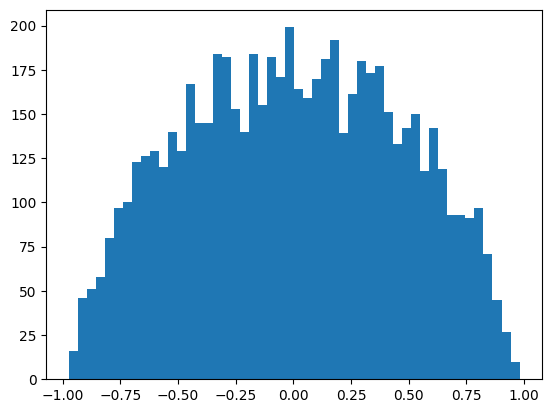

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad
    break


plt.hist(h.view(-1).tolist(),50)

(array([  2.,   2.,   2.,   5.,   3.,  10.,  20.,  19.,  20.,  41.,  37.,
         61.,  65., 106., 145., 160., 188., 224., 268., 275., 374., 325.,
        382., 403., 397., 386., 365., 360., 331., 257., 242., 199., 180.,
        113.,  92.,  93.,  87.,  54.,  27.,  26.,  25.,  10.,   7.,   4.,
          2.,   2.,   2.,   1.,   0.,   1.]),
 array([-2.1581254 , -2.06867666, -1.97922791, -1.88977917, -1.80033043,
        -1.71088169, -1.62143294, -1.5319842 , -1.44253546, -1.35308671,
        -1.26363797, -1.17418923, -1.08474049, -0.99529174, -0.905843  ,
        -0.81639426, -0.72694551, -0.63749677, -0.54804803, -0.45859929,
        -0.36915054, -0.2797018 , -0.19025306, -0.10080431, -0.01135557,
         0.07809317,  0.16754191,  0.25699066,  0.3464394 ,  0.43588814,
         0.52533689,  0.61478563,  0.70423437,  0.79368311,  0.88313186,
         0.9725806 ,  1.06202934,  1.15147809,  1.24092683,  1.33037557,
         1.41982431,  1.50927306,  1.5987218 ,  1.68817054,  1.77761929,
 

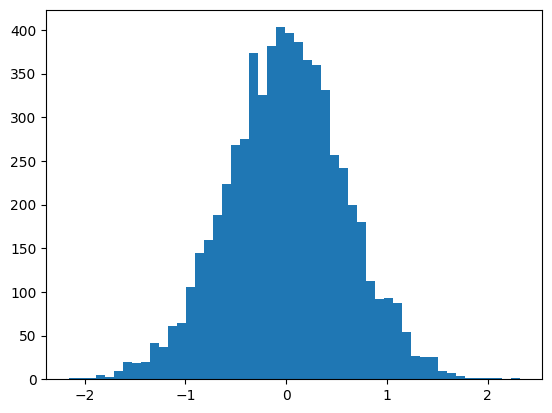

In [ ]:
plt.hist(hpreact.view(-1).tolist(),50)

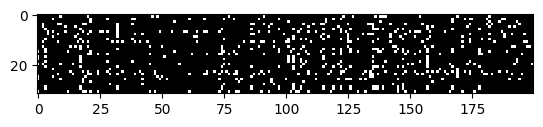

In [ ]:
plt.imshow(hpreact.abs()> 0.99, cmap = 'gray', interpolation='nearest')


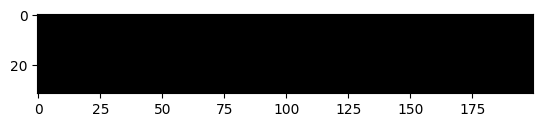

In [ ]:
plt.imshow(h.abs()> 0.99, cmap = 'gray', interpolation='nearest')


### Kaiming init

tensor(0.0090) tensor(1.0036)
tensor(-0.0074) tensor(7.8100)
tensor(0.0045) tensor(0.9971)


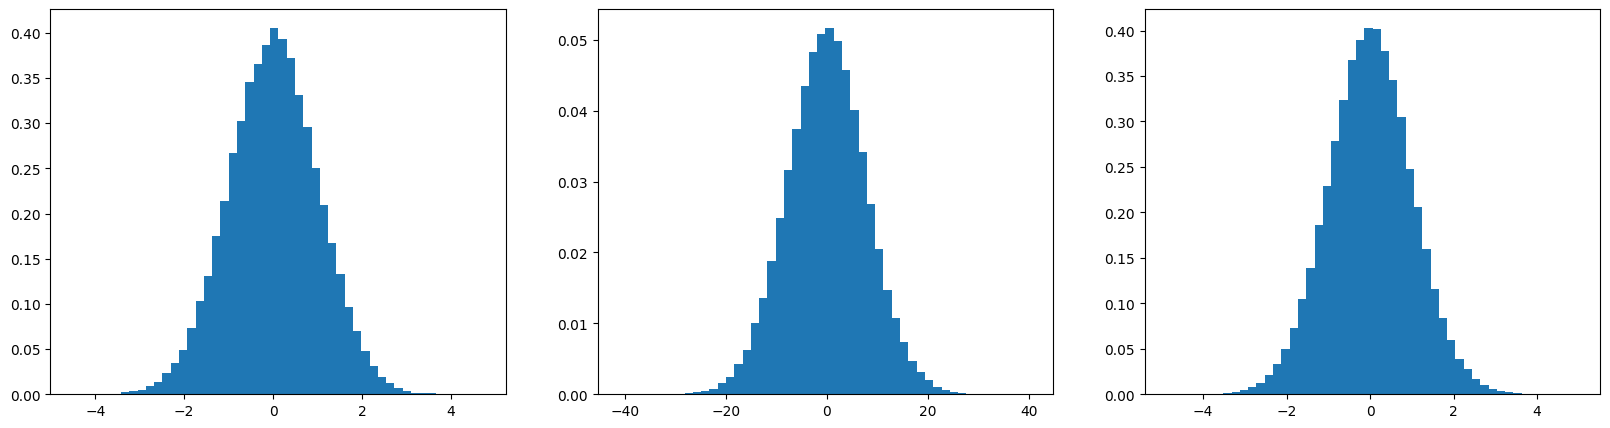

In [ ]:
# the intial W* __(some constant)
# the constant is derived from the kaiming rule

x = torch.randn(1000, 60)
w = torch.randn(60,200)* (1/60**0.5) #(1/ fan_in**0.5)
w1 = torch.randn(60,200)
y = x@w
y1 = x@w1
print(x.mean(), x.std())
print(y1.mean(), y1.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(131)
plt.hist(x.view(-1).tolist(),50, density=True)
plt.subplot(132)
plt.hist(y1.view(-1).tolist(), 50, density = True)
plt.subplot(133)
plt.hist(y.view(-1).tolist(), 50, density = True);
#Look the mean is almost same around 0 but std changes that is not what we want
# So, to tackle this we need to mukltiply our W by some constant
# and figuring out the appropriate one is very crucial
# We can do hit and trial or we can go through this docs "https://docs.pytorch.org/docs/stable/nn.init.html"
# we have different scalars to multiply for different activation to achieve what we wanty to acheive.
# but with introduction to many different modent techniques
# like BN, LN, ADAM, LMSprop
# so, multiplying by 

In [ ]:
# with kaiming constant
n_embd = 10
n_hidden = 200
max_Step = 50001
lossi = []
gain= 5/3
std1 = gain/(n_embd*block_size)**0.5
std2 = gain/(n_hidden)**0.5
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)*std1
W1 = torch.randn(n_embd*block_size, n_hidden )*std1
b1 = (torch.rand(n_hidden))*std1
W2 = torch.randn(n_hidden, vocab_size)*std2
b2 = torch.randn(vocab_size)*std2
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad


11897
0th/ 50001: 3.648399591445923
5000th/ 50001: 2.4864661693573
10000th/ 50001: 2.3122398853302
15000th/ 50001: 2.247465133666992
20000th/ 50001: 2.0234622955322266
25000th/ 50001: 2.1991233825683594
30000th/ 50001: 2.3888049125671387
35000th/ 50001: 2.6230416297912598
40000th/ 50001: 2.307833433151245
45000th/ 50001: 1.9735229015350342
50000th/ 50001: 2.1867270469665527


In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    h1 = torch.tanh(emb.view(emb.shape[0],-1)@W1+b1)
    logits = h1@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.1650)
tensor(2.2003)


### BATCH NORMALIZATION(Controlling the statistics of activation)

In [ ]:
# The problem was that the h which was tanh(hpreact)
# h could take any value like that  like that previously seen tanh which could have anything on -1 and 1
# which could saturate everything which is bad for our network
# but this problem could be solved if hpreact was somehow not random but uniform i mean gaussian thing
# so, anywhere we desire before activation function we wanna make the elements to be gaussian in nature
# This is done via Batch normalization. Now we will discuss about it.
# and applyng Gaussian is also defrentiable.
# without tanh
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad
    break

11897
0th/ 50001: 3.5895016193389893


In [ ]:
print(hpreact.shape)
print(hpreact)
print(hpreact.mean(0, keepdim=True).shape)
print(hpreact.mean(0, keepdim=True))

In [ ]:
hpreact.mean(0, keepdim=True)
hpreact.std(0, keepdim = True)
7

7

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
# bnmean_running = torch.ones(1, n_hidden)
# bnstd_running = torch.zeros(1, n_hidden)
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    # hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True)
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi  = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact- bnmeani)/bnstdi +bnbias
    # with torch.nograd():
    #     bnmean_running += bnmean_running*0.999 + bnmeani*0.001 # Concept of exponential moving average "Hamare yaha aisa hi hota hei type thing"
    #     bnstd_running += bnstd_running*0.999 + bnstdi*0.001
    # h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad
    # break


11897
0th/ 50001: 3.577587604522705
5000th/ 50001: 1.8095356225967407
10000th/ 50001: 2.266663074493408
15000th/ 50001: 2.29022479057312
20000th/ 50001: 2.3300037384033203
25000th/ 50001: 2.1723744869232178
30000th/ 50001: 2.3147361278533936
35000th/ 50001: 2.1106181144714355
40000th/ 50001: 1.9936350584030151
45000th/ 50001: 2.0511891841888428
50000th/ 50001: 2.092235565185547


In [ ]:
print(emb.shape)
print((hpreact- hpreact.mean(0, keepdim = True)).shape)
#(A)hpreact -> (32,200) , (B)hpreact.mean() == (C)hpreact.std() -> (1,200),  
#  A(32,200)
#            -(y)(32,200)
# B(1, 200)              /(32, 200) 
#             (C)(1, 200)
# 
print((bngain*((hpreact- hpreact.mean(0, keepdim = True))/ hpreact.std(0, keepdim = True)+bnbias)).shape)


bngain.shape
loss

torch.Size([32, 3, 10])
torch.Size([32, 200])
torch.Size([32, 200])


tensor(2.0922, grad_fn=<NllLossBackward0>)

Now with this above modification of  

```python 
hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True)

```
it is good but it limits our network to always centralise the data to mean of 0 and standard deviation of 0. so if there is a way to shift the distribution itself to overcome the limiting factor it would be great. 
So, for that we need some more knowledge
scale and shift == bngain and bnshift
to make the value

`y = scale*norm_data +shift`
at intial the scale will be all 1 and shift will be 0 but after that it is learnt through the backpropagation. 
So, new code is

```python 
hpreact = bngain * (hpreact- hpreact.mean(0, keepdim = True))/hpreact.std(0, keepdim = True) +bnbias
```
 


In [ ]:
# Initial shapes
print("=== INITIAL SHAPES ===")
print(f"hpreact shape: {hpreact.shape}")           # (32, 200)
print(f"bngain shape: {bngain.shape}")             # (1, 200)
print(f"bnbias shape: {bnbias.shape}")             # (1, 200)

# Step-by-step breakdown
print("\n=== STEP 1: Calculate mean ===")
mean = hpreact.mean(0, keepdim=True)
print(f"mean shape: {mean.shape}")                 # (1, 200)
print(f"Computes mean across batch (dim=0), keeps dimension")

print("\n=== STEP 2: Calculate std ===")
std = hpreact.std(0, keepdim=True)
print(f"std shape: {std.shape}")                   # (1, 200)

print("\n=== STEP 3: Center (subtract mean) ===")
centered = hpreact - mean
print(f"hpreact: {hpreact.shape}")                 # (32, 200)
print(f"mean:    {mean.shape}")                    # (1, 200)
print(f"result:  {centered.shape}")                # (32, 200)
print("Broadcasting: (32,200) - (1,200) → (32,200)")
print("Each row subtracts the same (1,200) mean vector")

print("\n=== STEP 4: Normalize (divide by std) ===")
normalized = centered / std
print(f"centered: {centered.shape}")               # (32, 200)
print(f"std:      {std.shape}")                    # (1, 200)
print(f"result:   {normalized.shape}")             # (32, 200)
print("Broadcasting: (32,200) / (1,200) → (32,200)")

print("\n=== STEP 5: Scale (multiply by bngain) ===")
scaled = bngain * normalized
print(f"bngain:     {bngain.shape}")               # (1, 200)
print(f"normalized: {normalized.shape}")           # (32, 200)
print(f"result:     {scaled.shape}")               # (32, 200)
print("Broadcasting: (1,200) * (32,200) → (32,200)")
print("Each row multiplied by the same (1,200) gain vector")

print("\n=== STEP 6: Shift (add bnbias) ===")
final = scaled + bnbias
print(f"scaled:  {scaled.shape}")                  # (32, 200)
print(f"bnbias:  {bnbias.shape}")                  # (1, 200)
print(f"result:  {final.shape}")                   # (32, 200)
print("Broadcasting: (32,200) + (1,200) → (32,200)")

print("\n=== BROADCASTING RULE ===")
print("When shapes differ:")
print("  - Align shapes from the right")
print("  - Dimensions of size 1 are stretched to match")
print("  (32, 200)")
print("  ( 1, 200)  ← dimension 0 is stretched 32 times")
print("  ---------")
print("  (32, 200)")


BN comes with some unwanted sideeffects but that is kind of a good news
why i mean all that is because BN is calculating each and every other neurons value to get the mean and standard deviation which tries to fight the idea of a single neuron getting only it's inputted value's information with BN the neuron now get the sense of other input's idea which turns out to be a good news because the learning of the neural net gets some randomness and in conclusion the BN positively affect the learning but this idea is debatable with respect to what we are trying to achieve and what is our goal. So, there are other methods introduced like (Layer, Group, Instance)normalization.
But people can't overlook the effectiveness of BN. So, we are still using it for many neuralnets

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    hpreact = emb.view(emb.shape[0],-1)@W1+b1
    hpreact = bngain*(hpreact - hpreact.mean(0, keepdim=True)/hpreact.std(0, keepdim = True))+bnbias
    h = torch.tanh(hpreact)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
print(hpreact.shape)
split_loss('val')


tensor(2.1577)
torch.Size([32, 200])
tensor(2.1956)


Now, while inferencing our current approach expects a batch but we don't have that. So, what do we do? 1st approach 
is to precalculate the mean and std of the whole training set or whatever we want to check on and use that  the following codeblock will have a glimpse of that
and use that in above codeblock as 
```python
hpreact = bngain*((hpreact - tr_bnmean)/tr_bnstd)+bnbias
```

In [ ]:
with torch.no_grad():
    emb = C[Xtr]
    hpreact = emb.view(emb.shape[0],-1)@ W1 +b1
    tr_bnmean, tr_bnstd = hpreact.mean(0, keepdim=True), hpreact.std(0, keepdim = True)

with torch.no_grad():
    emb = C[Xdev]
    hpreact = emb.view(emb.shape[0],-1)@ W1 +b1
    val_bnmean, val_bnstd = hpreact.mean(0, keepdim=True), hpreact.std(0, keepdim = True)


In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y,m, s= {
        'train': (Xtr, Ytr, tr_bnmean, tr_bnstd),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev, val_bnmean, val_bnstd)
    }[split]
    emb = C[x]
    hpreact = emb.view(emb.shape[0],-1)@W1+b1
    hpreact = bngain*((hpreact - m)/s)+bnbias
    h = torch.tanh(hpreact)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
# print(hpreact.shape)
split_loss('val')

tensor(2.1503)
tensor(2.1875)


And the people who wrote this paper of BN because apparantely everyone is lazy didn't wanted to do this. They wanted to calculate the mean std what to put there while it is running only and yes, they proposed the same idea in the paper as well.
Now, We will see this.

The code has been updated below now the bnmean_running and bnstd_running could be directly used in above instead of explicitly finding the value


In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
# b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.ones(1, n_hidden)
bnstd_running = torch.zeros(1, n_hidden)
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 #+b1
    # hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True)
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi  = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact- bnmeani)/bnstdi +bnbias
    with torch.no_grad():
        bnmean_running = bnmean_running*0.999 + bnmeani*0.001 # Concept of exponential moving average "Hamare yaha aisa hi hota hei type thing"
        bnstd_running = bnstd_running*0.999 + bnstdi*0.001
    h= torch.tanh(hpreact)
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad
    # break


11897
0th/ 50001: 3.784074544906616
5000th/ 50001: 2.0474631786346436
10000th/ 50001: 2.538156509399414
15000th/ 50001: 2.3434627056121826
20000th/ 50001: 2.0162112712860107
25000th/ 50001: 2.477994203567505
30000th/ 50001: 2.126506805419922
35000th/ 50001: 2.374422311782837
40000th/ 50001: 2.2892584800720215
45000th/ 50001: 2.2416088581085205
50000th/ 50001: 1.9590141773223877


In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y,m, s= {
        'train': (Xtr, Ytr, tr_bnmean, tr_bnstd),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev, val_bnmean, val_bnstd)
    }[split]
    emb = C[x]
    hpreact = emb.view(emb.shape[0],-1)@W1+b1
    hpreact = bngain*((hpreact - bnmean_running)/bnstd_running)+bnbias
    h = torch.tanh(hpreact)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
# print(hpreact.shape)
split_loss('val')

tensor(2.1647)
tensor(2.1991)


In [ ]:
tr_bnmean - bnmean_running # Very low (Similar values)

tensor([[ 0.0153, -0.0383, -0.0235,  0.0093, -0.0406, -0.0517, -0.0053,  0.0005,
         -0.0042, -0.0066,  0.0002,  0.0335, -0.0018, -0.0072, -0.0012,  0.0192,
         -0.0055,  0.0436, -0.0375, -0.0111,  0.0144, -0.0144, -0.0082,  0.0257,
         -0.0108, -0.0262, -0.0098, -0.0368, -0.0293, -0.0079,  0.0139, -0.0003,
         -0.0357, -0.0044, -0.0170,  0.0072,  0.0557, -0.0019, -0.0236,  0.0105,
         -0.0103, -0.0064,  0.0174,  0.0047, -0.0213,  0.0200, -0.0419, -0.0049,
         -0.0173, -0.0186, -0.0506,  0.0163, -0.0360,  0.0396, -0.0070, -0.0369,
         -0.0338, -0.0212,  0.0105,  0.0331,  0.0240,  0.0294, -0.0026, -0.0311,
         -0.0222,  0.0129,  0.0172,  0.0153, -0.0492,  0.0169, -0.0026, -0.0141,
          0.0200,  0.0020,  0.0048,  0.0094,  0.0065, -0.0185,  0.0100, -0.0171,
          0.0095, -0.0453, -0.0077,  0.0094, -0.0202,  0.0499,  0.0039,  0.0045,
          0.0033, -0.0061, -0.0010, -0.0041, -0.0167, -0.0495, -0.0209, -0.0129,
         -0.0014,  0.0865, -

We haven't discussed about epsilon to make it stable to make it non-infinity and make the operation more well-behaved
and we need not use bias in hpreact and we are again kind of subtracting it when we subtract the mean and BN itself has it's own bias in this notebook named as `bnbias` and that will do the work so, we need not define b1 and need not add it doesn't affect catastrophically but it is kind of a waste.

## WITHOUT TANH

In [ ]:
# without tanh
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*0.1
b1 = (torch.rand(n_hidden))*0.001
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0
parameters = [C, W1, W2, b1, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    hpreact = emb.view(emb.shape[0], -1) @W1 +b1
    h= hpreact
    logits = h@W2 +b2
    # print(logits.shape)
    loss = F.cross_entropy(logits, Yb)
    if i%5000 ==0:
        print(f'{i}th/ {max_steps}: {loss}')
    lossi.append(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.05*p.grad


11897
0th/ 50001: 3.341076374053955
5000th/ 50001: 2.562345027923584
10000th/ 50001: 2.3047051429748535
15000th/ 50001: 2.4471592903137207
20000th/ 50001: 2.164726734161377
25000th/ 50001: 2.338881492614746
30000th/ 50001: 1.914414882659912
35000th/ 50001: 2.185006856918335
40000th/ 50001: 2.6520369052886963
45000th/ 50001: 2.528061628341675
50000th/ 50001: 2.056457757949829


In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    emb = C[x]
    h1 = torch.tanh(emb.view(emb.shape[0],-1)@W1+b1)
    logits = h1@W2 +b2
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.3301)
tensor(2.3392)


In [ ]:
# @torch.no_grad()
g =torch.Generator().manual_seed(7607665605+10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(emb.shape[0], -1) @W1 +b1)
        logits = h@W2 +b2
        prob = torch.softmax(logits,dim = 1)
        # print(prob)
        ix = torch.multinomial(prob,num_samples = 1,generator = g, replacement = True).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix ==0:
            break
    
    print(''.join(out))

muvyenay.
jatomlanon.
jyanant.
bonesaemmire.
nel.
jbittono.
baiekaef.
fian.
buer.
zalornieed.
nyly.
tre.
jaef.
niza.
ranamarici.
dentorna.
nathan.
elahe.
jeednalema.
bai.


In [ ]:
#In huge neural network the machiine will stop learning
#  because of bad intialization of weights and biases

## Pytorchifying stuff

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out 
        self.isbias = bias
        self.bias = torch.zeros(fan_out) if bias else None
        self.weights = torch.randn(fan_in, fan_out)/ fan_in**0.5
        self.out = None

    def __call__(self, x):
        # print(x.dtype)
        # print(self.weights.dtype)
        self.out = x @ self.weights
        # print(self.bias)
        return self.out + self.bias if self.isbias else self.out

    def parameters(self):
        params = [self.weights] + ([self.bias] if self.isbias is not None else [])
        for i, p in enumerate(params):
            print(f"Parameter {i}: shape = {tuple(p.shape)}")
        return params
        
        
    

class BatchNorm1D:
    def __init__(self, dim,epsilon = 1e-05, momentum = 0.00001):
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)  
        self.running_std = torch.ones(dim)
        self.eps = epsilon
        self.momentum = momentum

    def __call__(self, x):
        if self.training:
            x_mean  = x.mean(0, keepdim = True)
            x_std = x.var(0, keepdim = True )
        else:
            x_mean = self.running_mean
            x_std = self.running_std

        self.out = self.gamma * ((x - x_mean)/torch.sqrt(x_std+ self.eps)) + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean  = self.momentum*x_mean  + (1- self.momentum)*self.running_mean
                self.running_std  = self.momentum*x_std  + (1- self.momentum)*self.running_std
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
vocab = sorted(list(set(''.join(words))))
stoi = { x:i+1 for i,x in enumerate(vocab)}
stoi['.'] = 0
print(stoi)
itos = { x:i for i,x in stoi.items()}

# itos = { in (stoi.items())}

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
block_size = 3
import torch


def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182485, 3]) torch.Size([182485])
torch.Size([22822, 3]) torch.Size([22822])
torch.Size([22846, 3]) torch.Size([22846])


In [198]:
import torch
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), Tanh(),
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  0.5 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)
p

36397


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.], requires_grad=True)

In [199]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())

    break

0 3.2957029342651367


layer 1 (      Tanh): mean +0.01, std: 0.76, saturated: 22.59
layer 3 (      Tanh): mean -0.01, std: 0.68, saturated: 9.28
layer 5 (      Tanh): mean +0.02, std: 0.67, saturated: 7.12
layer 7 (      Tanh): mean -0.03, std: 0.67, saturated: 7.03


Text(0.5, 1.0, 'activation distribution')

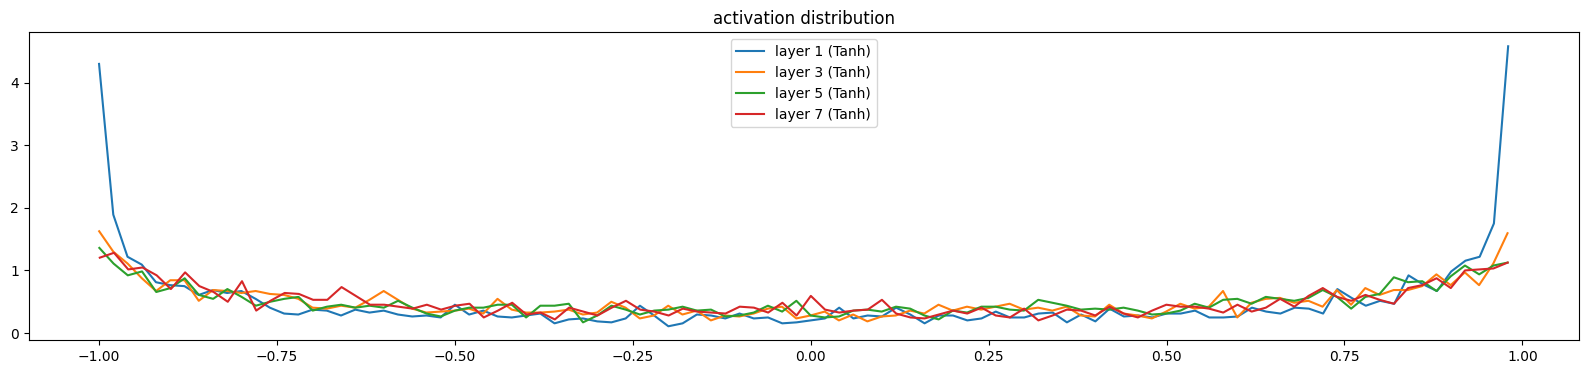

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


# when the gain = 5/3

plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

See the value stabalizes as it goes deep into the neuralnet.
```python
for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=5/3
```
as this value is 5/3 which was proved in kaiming thing this does the work to stabilise everything.
For comparision i will also paste the histogram when it is multiplied by 1 instead of 5/3 below. 


layer 1 (      Tanh): mean +0.00, std: 0.64, saturated: 5.22
layer 3 (      Tanh): mean +0.00, std: 0.49, saturated: 0.00
layer 5 (      Tanh): mean -0.00, std: 0.42, saturated: 0.00
layer 7 (      Tanh): mean -0.00, std: 0.37, saturated: 0.00


Text(0.5, 1.0, 'activation distribution')

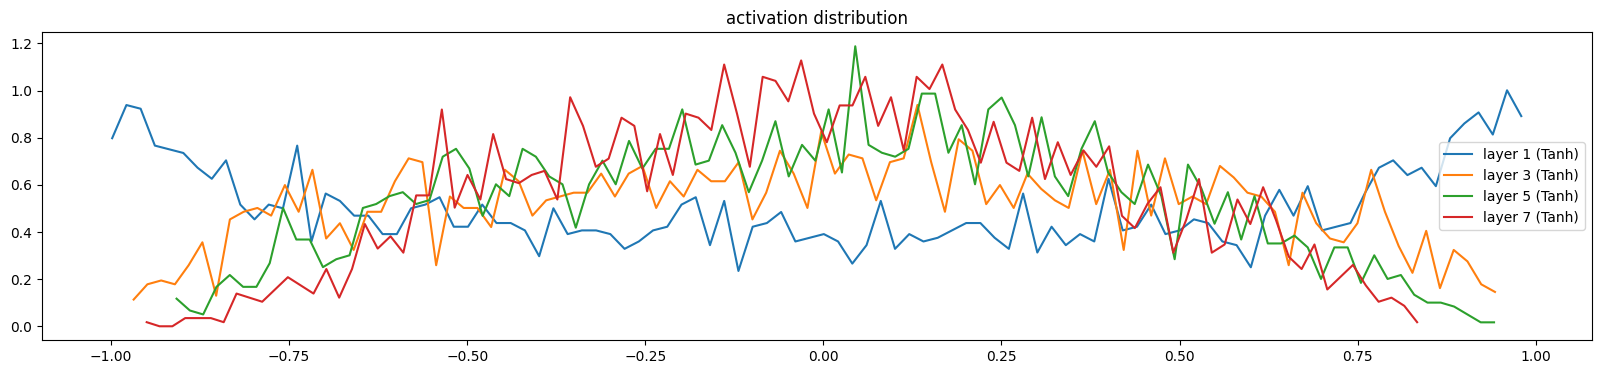

In [ ]:
# when the gain = 1
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

See now the values are very messy because the tanh function just squashes the value that we got so going deeper it makes everything with very high messiness(can we say that here?)
And also for the gradient graph.

layer 1 (      Tanh): mean -0.000008, std: 3.647955e-04
layer 3 (      Tanh): mean +0.000010, std: 3.649798e-04
layer 5 (      Tanh): mean +0.000001, std: 3.449208e-04
layer 7 (      Tanh): mean +0.000020, std: 3.107263e-04


Text(0.5, 1.0, 'gradient distribution')

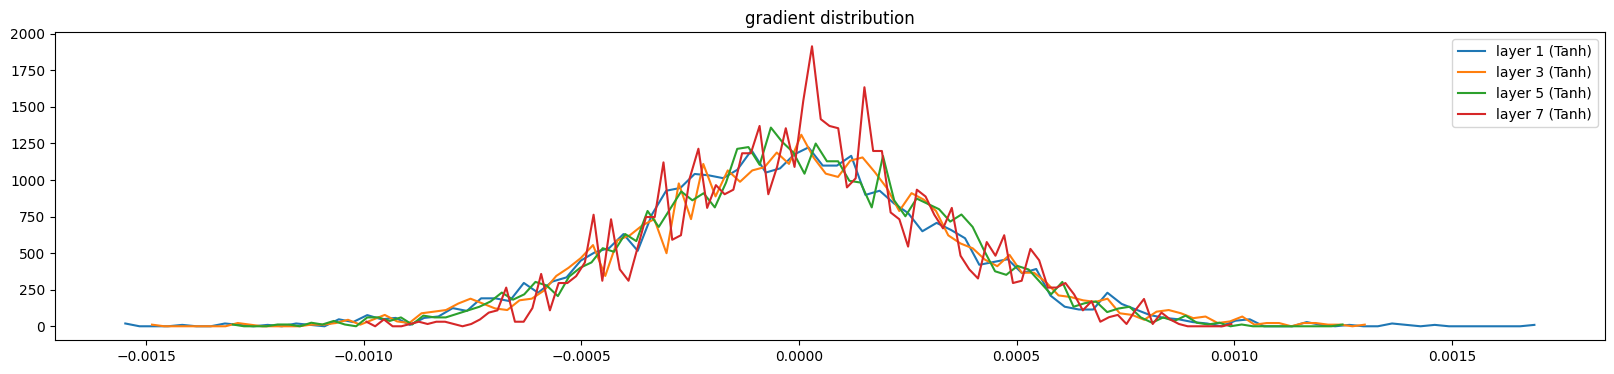

In [197]:
# when the gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 1 (      Tanh): mean -0.000000, std: 3.880961e-05
layer 3 (      Tanh): mean -0.000001, std: 7.669503e-05
layer 5 (      Tanh): mean +0.000006, std: 1.507005e-04
layer 7 (      Tanh): mean -0.000014, std: 3.091932e-04


Text(0.5, 1.0, 'gradient distribution')

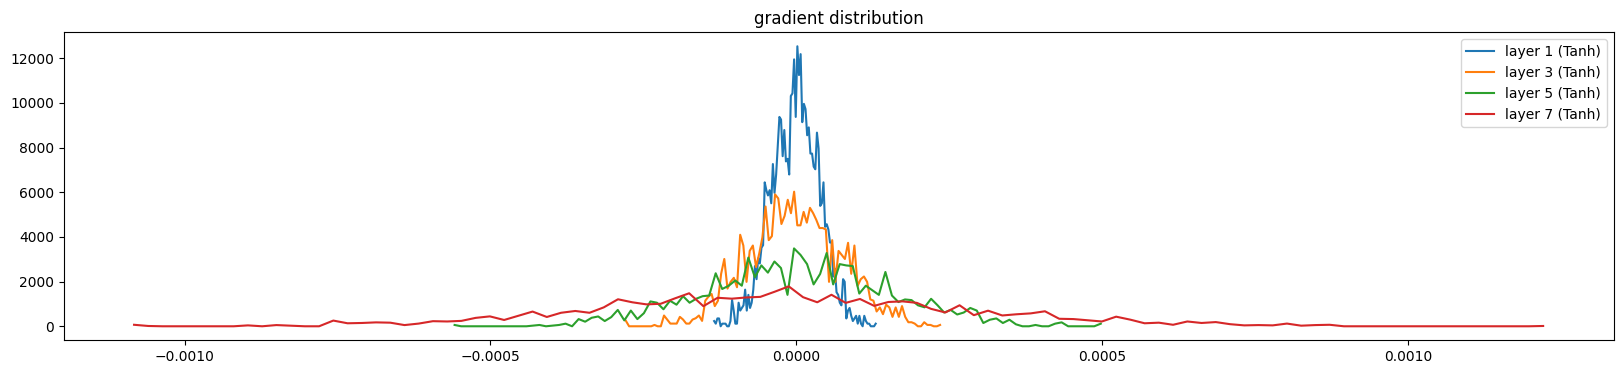

In [ ]:
# when the gain = 0.5
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

### with no tanh

In [205]:

import torch
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), #Tanh(),
    Linear(hidden_dim, hidden_dim), #Tanh(),   
    Linear(hidden_dim, hidden_dim), #Tanh(),   
    Linear(hidden_dim, hidden_dim), #Tanh(),   
    Linear(hidden_dim, vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  5/3 # 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)


36397


27

In [206]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())

    break

0 3.608593225479126


layer 0 (    Linear): mean -0.000006, std: 2.843356e-04
layer 1 (    Linear): mean +0.000007, std: 2.907957e-04
layer 2 (    Linear): mean -0.000011, std: 2.983535e-04
layer 3 (    Linear): mean -0.000022, std: 3.134614e-04


Text(0.5, 1.0, 'activation distribution')

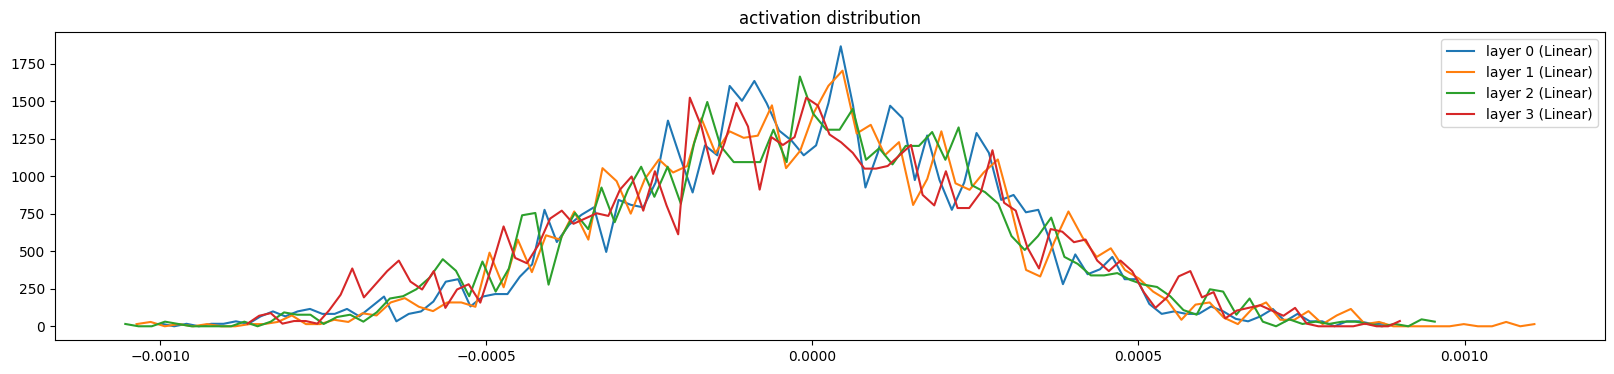

In [ ]:
#with no tanh and gain = 1
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 0 (    Linear): mean -0.000019, std: 1.414877e-03
layer 1 (    Linear): mean -0.000020, std: 9.004226e-04
layer 2 (    Linear): mean +0.000005, std: 5.347018e-04
layer 3 (    Linear): mean -0.000002, std: 3.147698e-04


Text(0.5, 1.0, 'activation distribution')

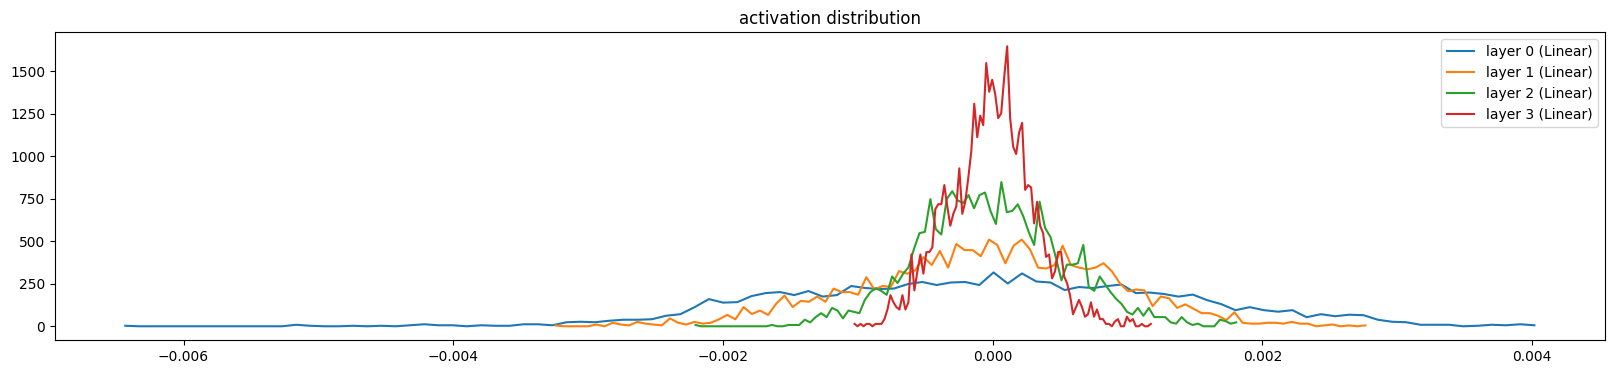

In [ ]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 0 (    Linear): mean -0.01, std: 1.09, saturated: 36.72
layer 1 (    Linear): mean -0.02, std: 1.10, saturated: 37.09
layer 2 (    Linear): mean +0.07, std: 1.06, saturated: 34.19
layer 3 (    Linear): mean -0.02, std: 1.06, saturated: 35.50


Text(0.5, 1.0, 'activation distribution')

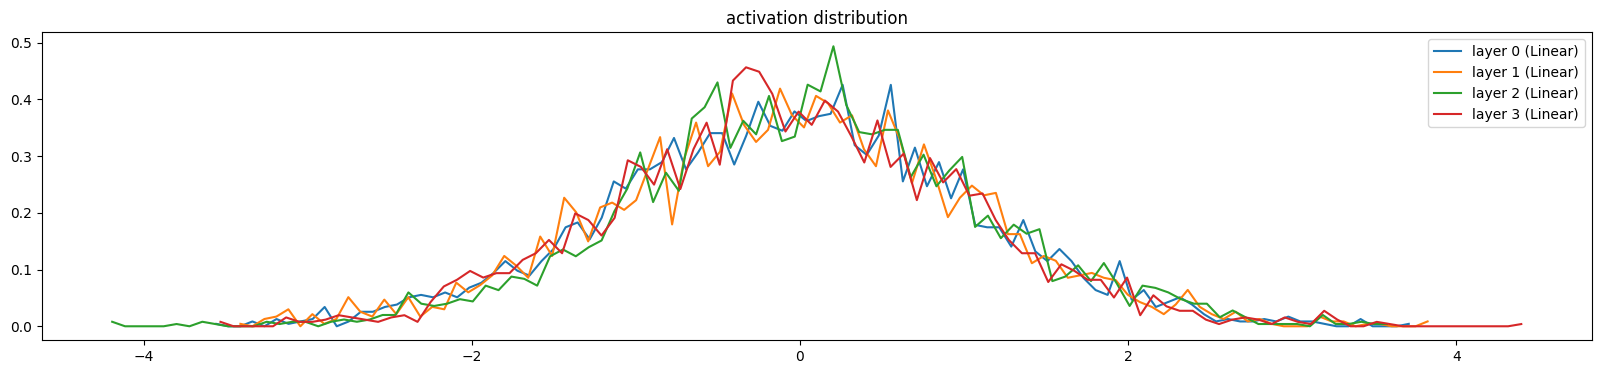

In [ ]:
# with no tanh gain = 1
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

layer 0 (    Linear): mean -0.07, std: 1.77, saturated: 58.88
layer 1 (    Linear): mean +0.01, std: 3.00, saturated: 73.06
layer 2 (    Linear): mean +0.12, std: 4.87, saturated: 85.81
layer 3 (    Linear): mean -0.50, std: 7.86, saturated: 90.47


Text(0.5, 1.0, 'activation distribution')

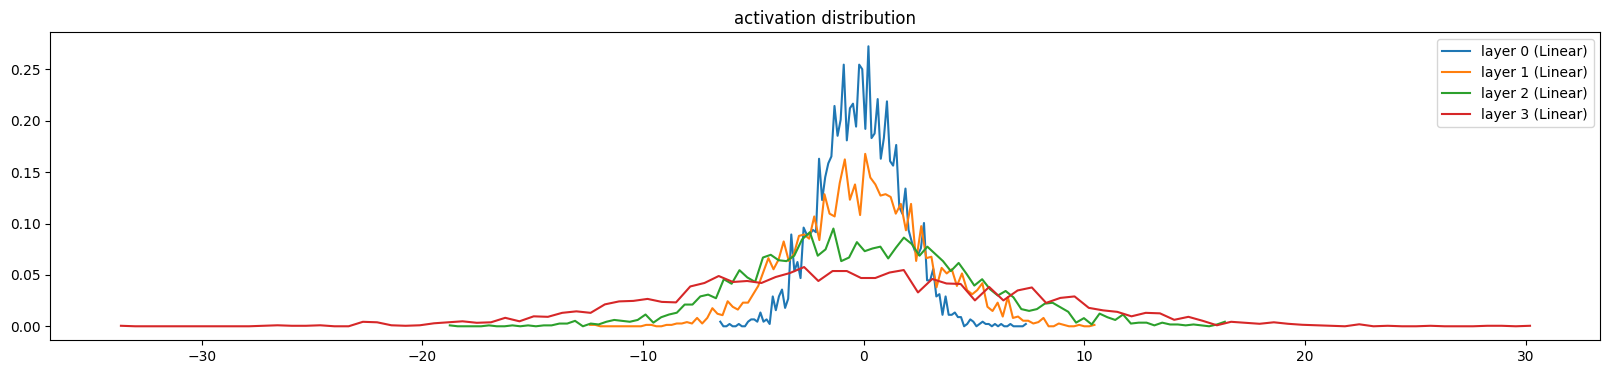

In [207]:
# with gain = 5/3
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

### with tanh thing again we're back baby and some new insights with visualizations

In [217]:
import torch
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), Tanh(),
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  5/3 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)
p

36397


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.], requires_grad=True)

In [ ]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())
    if i == 1000:
        break

0 3.2729175090789795


layer 1 (      Tanh): mean +0.03, std: 0.77, saturated: 25.50
layer 3 (      Tanh): mean -0.04, std: 0.69, saturated: 9.66
layer 5 (      Tanh): mean +0.03, std: 0.66, saturated: 7.19
layer 7 (      Tanh): mean -0.06, std: 0.64, saturated: 5.31


Text(0.5, 1.0, 'activation distribution')

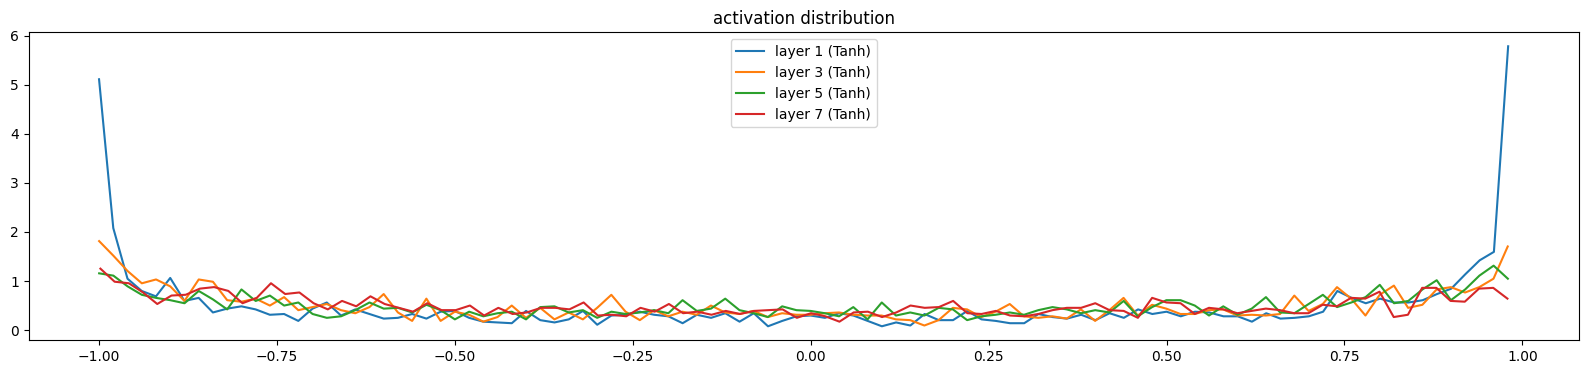

In [219]:
# with gain = 5/3
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

layer 1 (      Tanh): mean -0.000005, std: 3.626079e-04
layer 3 (      Tanh): mean -0.000015, std: 3.514316e-04
layer 5 (      Tanh): mean -0.000006, std: 3.236340e-04
layer 7 (      Tanh): mean +0.000009, std: 2.942865e-04


Text(0.5, 1.0, 'gradient distribution')

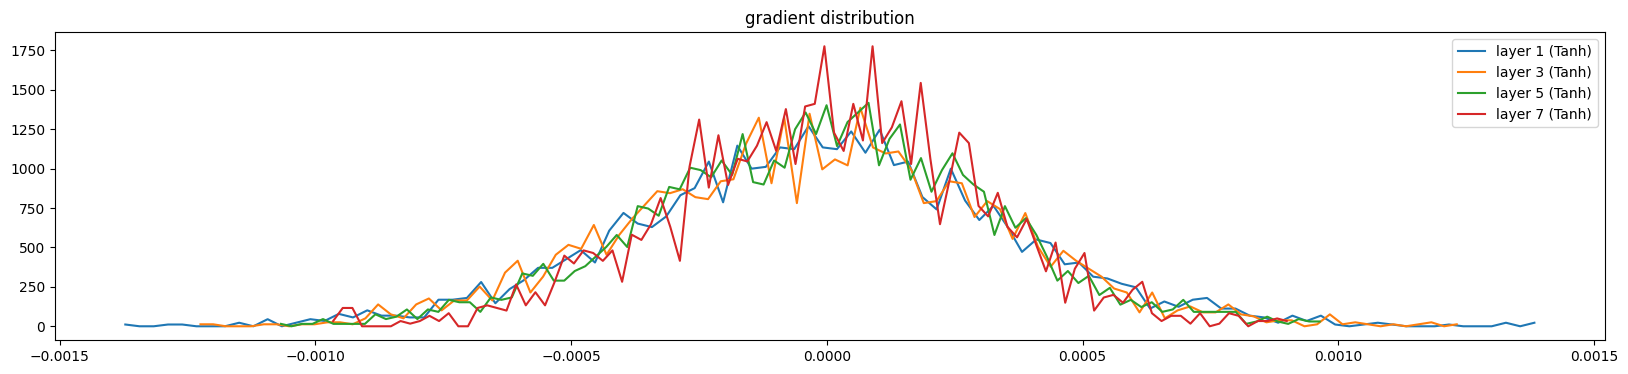

In [220]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

Now, This looks cool right? Wait,We can visualise 1 more thing the parameter itself. How they behave and stuff.

weight   (27, 10) | mean -0.000032 | std +1.084031e-03 | grad:data ratio 1.061273e-03
weight  (30, 100) | mean +0.000016 | std +1.353783e-03 | grad:data ratio 4.453823e-03
weight (100, 100) | mean -0.000006 | std +1.078460e-03 | grad:data ratio 6.440456e-03
weight (100, 100) | mean -0.000003 | std +9.324623e-04 | grad:data ratio 5.654835e-03
weight (100, 100) | mean +0.000013 | std +8.233822e-04 | grad:data ratio 4.964534e-03
weight  (100, 27) | mean -0.000000 | std +2.489761e-02 | grad:data ratio 2.495939e+00


Text(0.5, 1.0, 'weights gradient distribution')

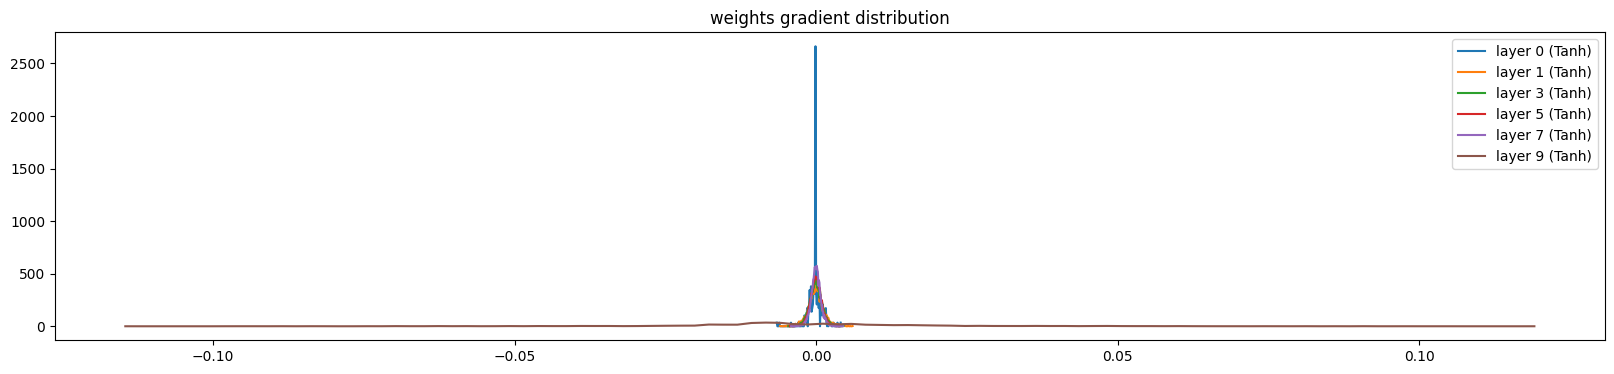

In [234]:
plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


Look above in the last layer the grad/ data ratio is pretty huge right? which is not optimal the healthy ratio is around ~1e-3 to 1e-2  → healthy so that's why we have that weird plot so, the last layer value is undesirable and troublemaker. So, Last layer has 10 times higher gradient than other layer.what it means by this is the final layer will train 10 times faster than other one which is not good. But if we train this for like higher iteration. This problem itself kind of reduces. In conclusion this is happening coz we are using simple SGD but if we use Adam and other cool optimizers this is not that big of an issue.

#### Longer training slightly to be precise [i==1000]

weight   (27, 10) | mean -0.001816 | std +9.537685e-03 | grad:data ratio 9.337516e-03
weight  (30, 100) | mean -0.000102 | std +8.735514e-03 | grad:data ratio 2.861614e-02
weight (100, 100) | mean +0.000133 | std +6.889437e-03 | grad:data ratio 4.070768e-02
weight (100, 100) | mean +0.000029 | std +6.109385e-03 | grad:data ratio 3.666562e-02
weight (100, 100) | mean -0.000087 | std +4.784871e-03 | grad:data ratio 2.861577e-02
weight  (100, 27) | mean -0.000000 | std +2.040716e-02 | grad:data ratio 2.848325e-01


Text(0.5, 1.0, 'weights gradient distribution')

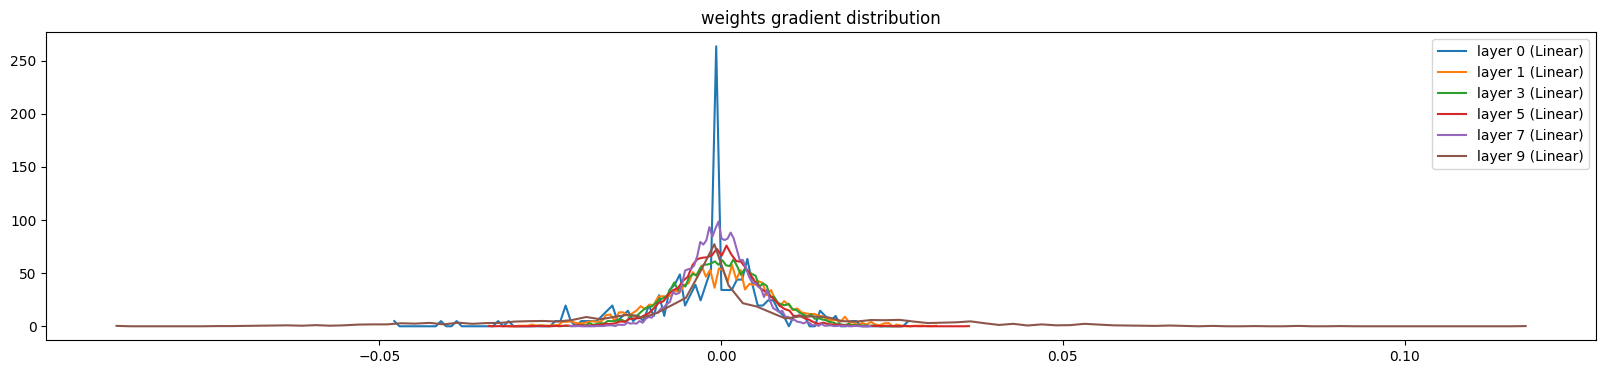

In [ ]:
# at i= 1000

plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


layer 1 (      Tanh): mean +0.02, std: 0.77, saturated: 23.53
layer 3 (      Tanh): mean -0.03, std: 0.72, saturated: 12.25
layer 5 (      Tanh): mean +0.07, std: 0.71, saturated: 10.97
layer 7 (      Tanh): mean -0.06, std: 0.70, saturated: 10.16


Text(0.5, 1.0, 'activation distribution')

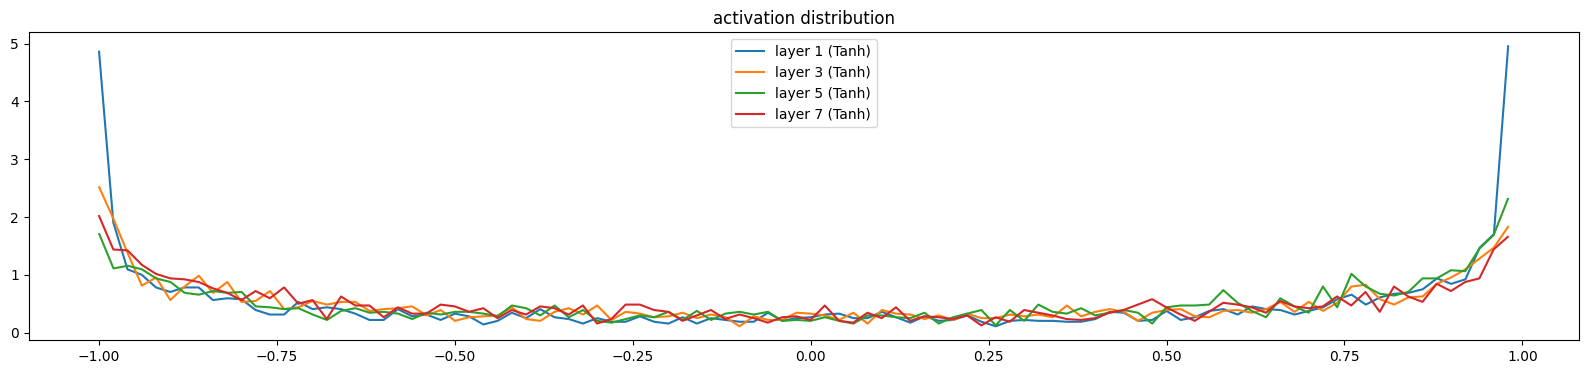

In [ ]:
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

layer 1 (      Tanh): mean -0.000039, std: 3.003326e-03
layer 3 (      Tanh): mean +0.000112, std: 2.833963e-03
layer 5 (      Tanh): mean +0.000007, std: 2.602230e-03
layer 7 (      Tanh): mean -0.000050, std: 2.302875e-03


Text(0.5, 1.0, 'gradient distribution')

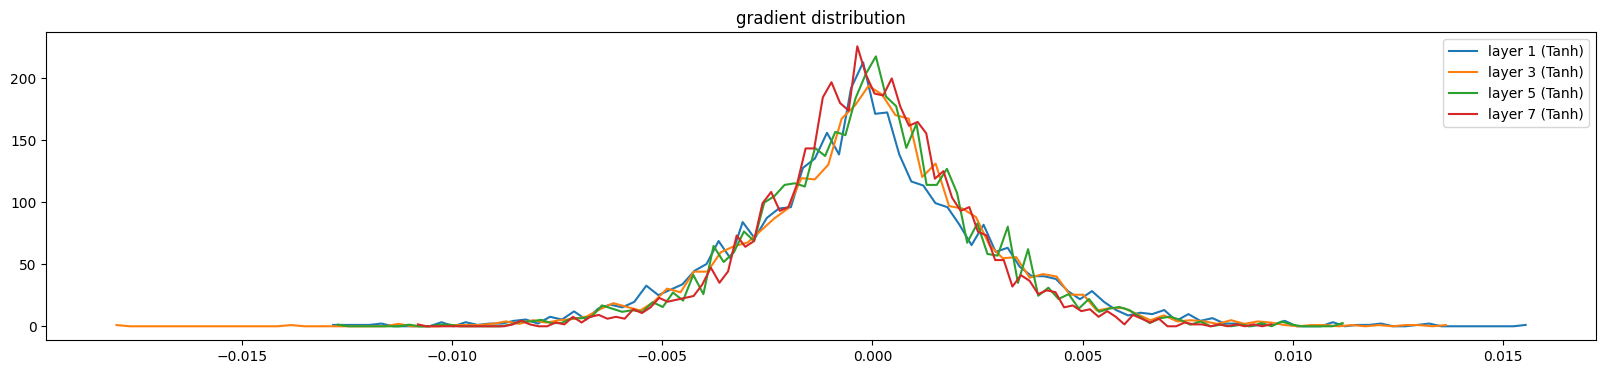

In [ ]:

plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

#### Update to data ratio

Above we have seen the grad:data ratio but in itself it isnot that informative so we wanna do something like update to data ratio.


In [ ]:
import torch
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), Tanh(),
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  5/3 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

3000+100*4 + 100*100*3 + 100*27 + 27+ 270

Parameter 0: shape = (30, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 27)
Parameter 1: shape = (27,)
36397


36397

In [ ]:
Ytr.shape
ix.shape
Xb.shape
Yb.shape
C[Xtr].shape
x.shape
emb.shape
# emb.view(emb.shape[0], -1).shape

torch.Size([32, 30])

In [383]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
ud = []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])
    lossilog.append(loss.log10().item())
    
    if i == 1000:
        break

0 3.207681655883789


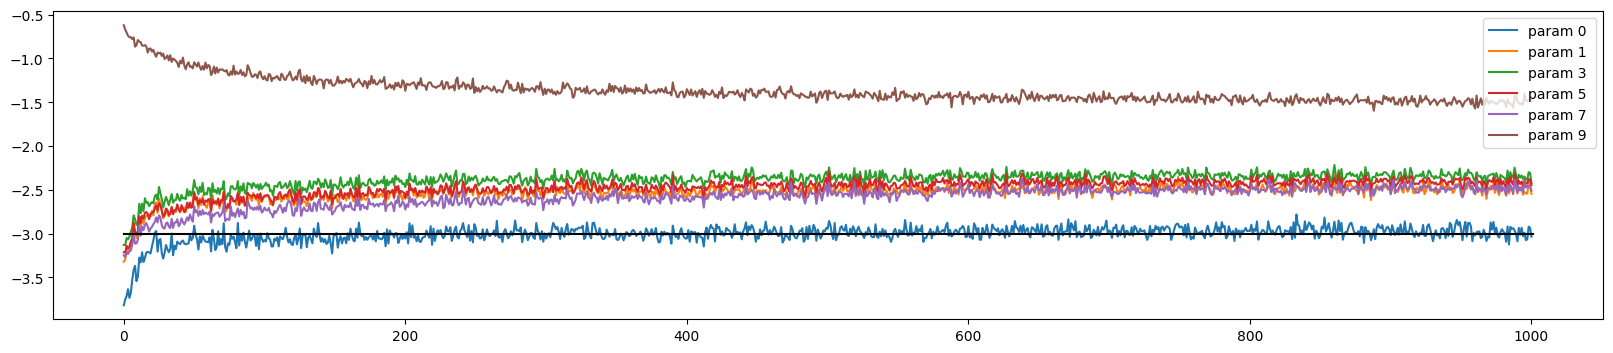

In [391]:
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

Above plot shows that this training is steady but if we try to  change some crucial parameter in this we could see it being messy and the algorithm doesn't let the neural net to learn well. Let's see what happens if we try to do that. 

In [41]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), Tanh(),
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  5/3 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

Parameter 0: shape = (30, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 100)
Parameter 1: shape = (100,)
Parameter 0: shape = (100, 27)
Parameter 1: shape = (27,)
36397


##### changing learning rate to see the plots

In [42]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
ud = []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])
    lossilog.append(loss.log10().item())
    
    if i == 1000:
        break

0 3.2956044673919678


weight   (27, 10) | mean +0.000041 | std +1.105272e-03 | grad:data ratio 1.082069e-03
weight  (30, 100) | mean +0.000008 | std +1.211362e-03 | grad:data ratio 4.034243e-03
weight (100, 100) | mean -0.000001 | std +9.336735e-04 | grad:data ratio 5.501389e-03
weight (100, 100) | mean +0.000007 | std +8.127184e-04 | grad:data ratio 4.870630e-03
weight (100, 100) | mean +0.000003 | std +7.203560e-04 | grad:data ratio 4.305750e-03
weight  (100, 27) | mean -0.000000 | std +2.160067e-02 | grad:data ratio 2.188658e+00


Text(0.5, 1.0, 'weights gradient distribution')

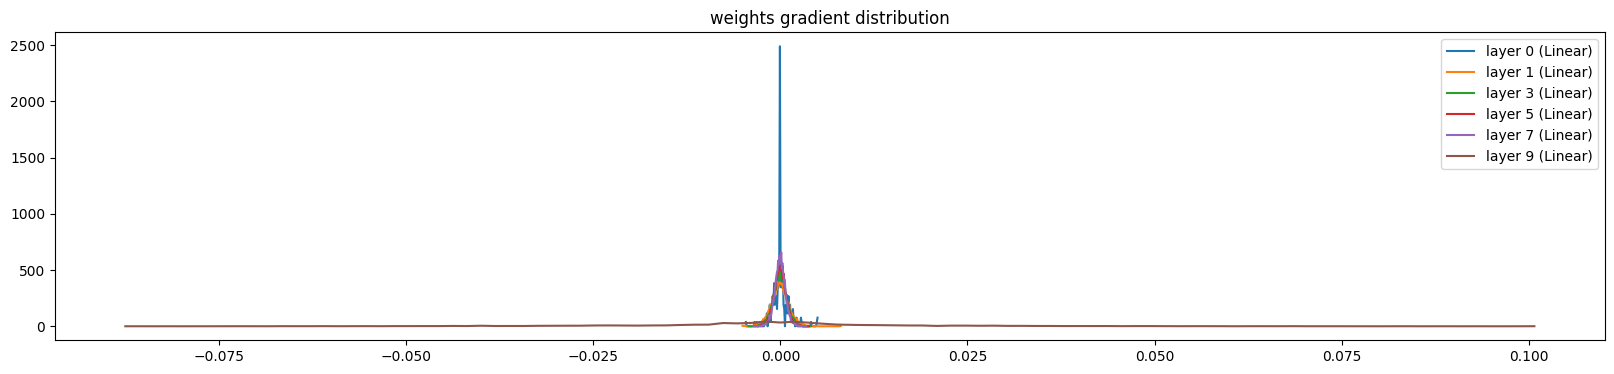

In [27]:
# at i= 1000

plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


layer 1 (      Tanh): mean +0.000003, std: 3.836447e-04
layer 3 (      Tanh): mean -0.000007, std: 3.703038e-04
layer 5 (      Tanh): mean -0.000003, std: 3.355953e-04
layer 7 (      Tanh): mean +0.000004, std: 3.060312e-04


Text(0.5, 1.0, 'gradient distribution')

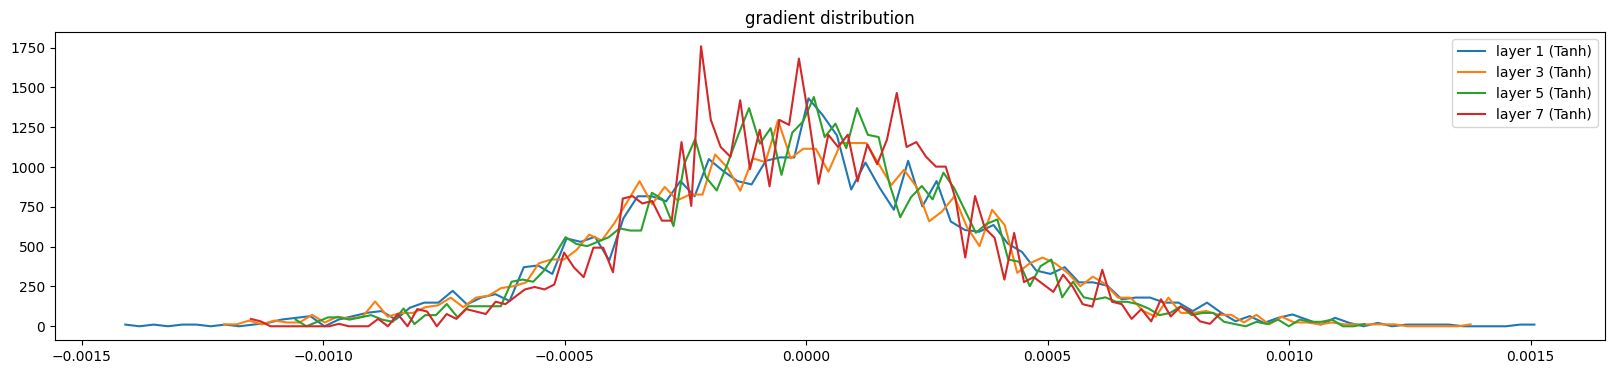

In [28]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 1 (      Tanh): mean +0.04, std: 0.76, saturated: 22.09
layer 3 (      Tanh): mean +0.03, std: 0.69, saturated: 10.41
layer 5 (      Tanh): mean +0.02, std: 0.66, saturated: 6.53
layer 7 (      Tanh): mean -0.00, std: 0.66, saturated: 5.59


Text(0.5, 1.0, 'activation distribution')

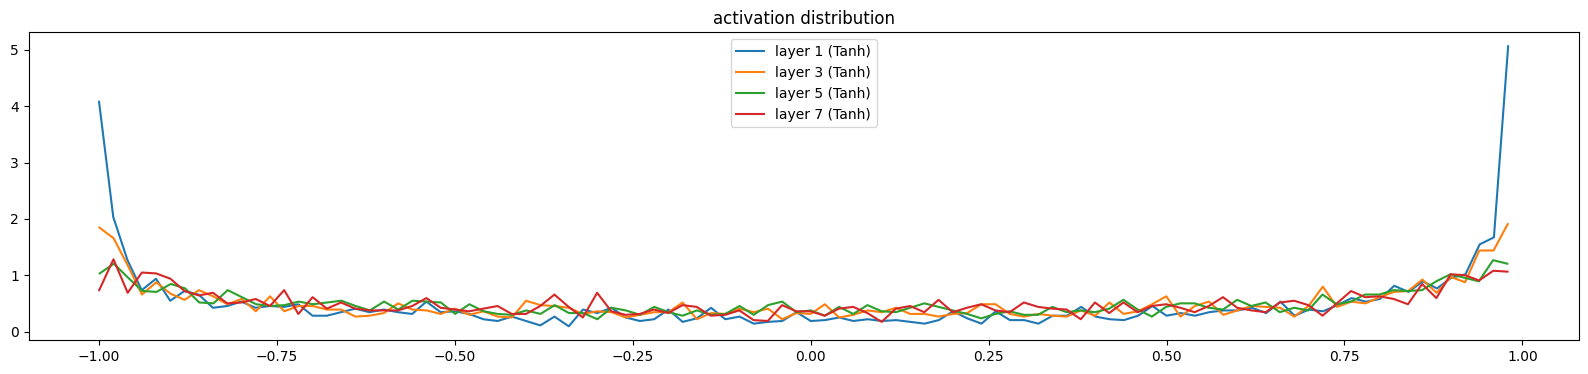

In [29]:
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

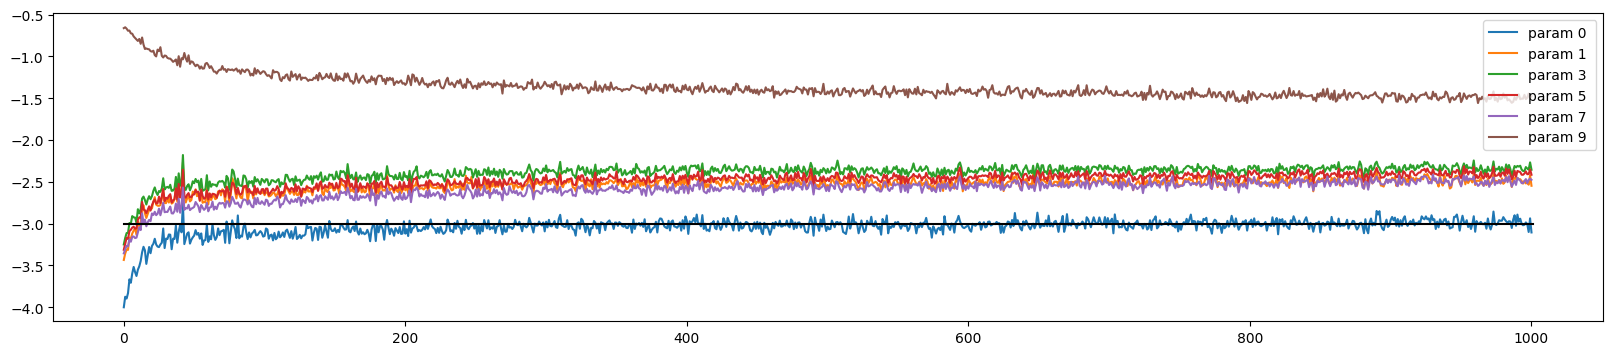

In [ ]:
#when lr = 0.1 (Good Training)
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

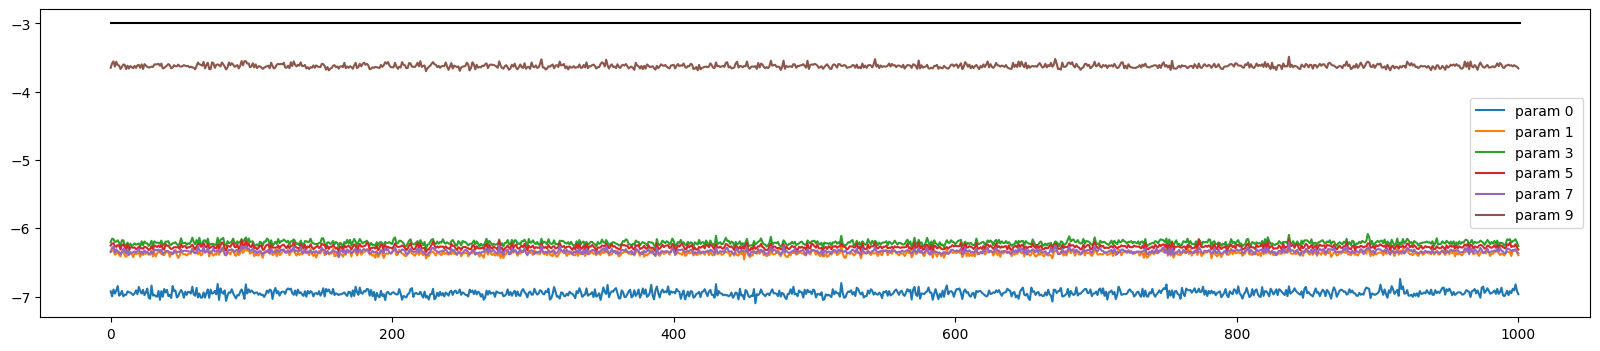

In [ ]:
#when lr = 0.0001( Slow training)
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

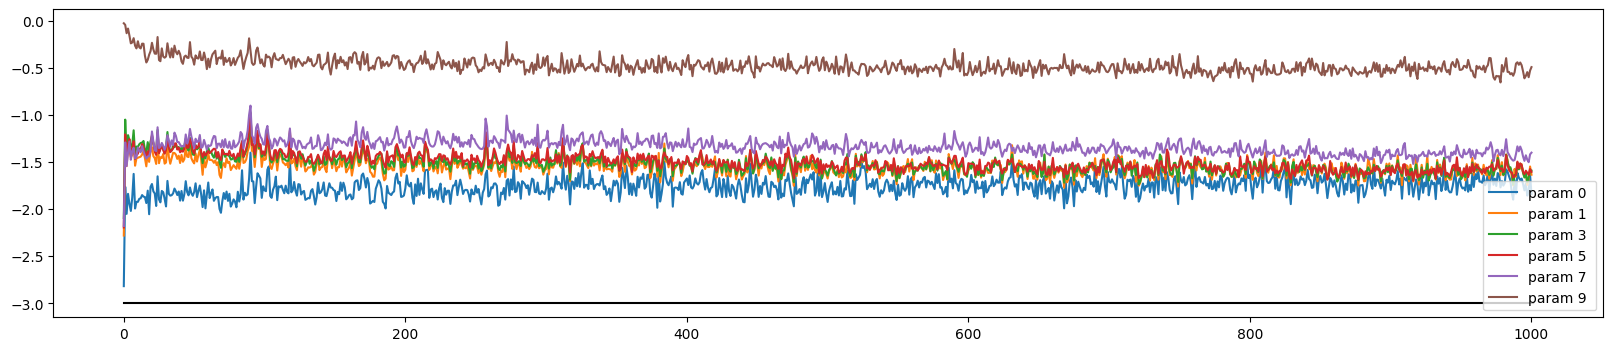

In [ ]:
#when lr = 1( Fast training)
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

##### without Using  vs using BatchNormalization to see how things react(forgeting to apply the kaiming rule)

In [107]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out 
        self.isbias = bias
        self.bias = torch.zeros(fan_out) if bias else None
        self.weights = torch.randn(fan_in, fan_out) #/ fan_in**0.5
        self.out = None

    def __call__(self, x):
        # print(x.dtype)
        # print(self.weights.dtype)
        self.out = x @ self.weights
        # print(self.bias)
        return self.out + self.bias if self.isbias else self.out

    def parameters(self):
        return [self.weights] + ([self.bias] if self.isbias is not None else [])
    

class BatchNorm1D:
    def __init__(self, dim,epsilon = 1e-5, momentum =0.1):
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)  
        self.running_std = torch.ones(dim)
        self.eps = epsilon
        self.momentum = momentum

    def __call__(self, x):
        if self.training:
            x_mean  = x.mean(0, keepdim = True)
            x_std = x.var(0, keepdim = True )
        else:
            x_mean = self.running_mean
            x_std = self.running_std

        self.out = self.gamma * ((x - x_mean)/torch.sqrt(x_std+ self.eps)) + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean  = self.momentum*x_mean  + (1- self.momentum)*self.running_mean
                self.running_std  = self.momentum*x_std  + (1- self.momentum)*self.running_std
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [120]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), BatchNorm1D(hidden_dim),Tanh(),
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim),Tanh(),   
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size),BatchNorm1D(vocab_size)
]

with torch.no_grad():
    # layers[-1].weights *= 0.1
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  1 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

37251


In [121]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
ud = []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 2 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])
    lossilog.append(loss.log10().item())
    
    if i == 1000:
        break

0 3.2589094638824463


###### without BN Plots

weight   (27, 10) | mean +0.008647 | std +1.478146e-01 | grad:data ratio 1.024680e-01
weight  (30, 100) | mean -0.001183 | std +5.476573e-02 | grad:data ratio 3.251937e-02
weight (100, 100) | mean -0.000045 | std +1.405986e-02 | grad:data ratio 8.418093e-03
weight (100, 100) | mean +0.000000 | std +5.511393e-03 | grad:data ratio 3.308680e-03
weight (100, 100) | mean -0.000021 | std +2.048986e-03 | grad:data ratio 1.224343e-03
weight  (100, 27) | mean -0.000000 | std +3.132088e-02 | grad:data ratio 4.394071e-01


Text(0.5, 1.0, 'weights gradient distribution')

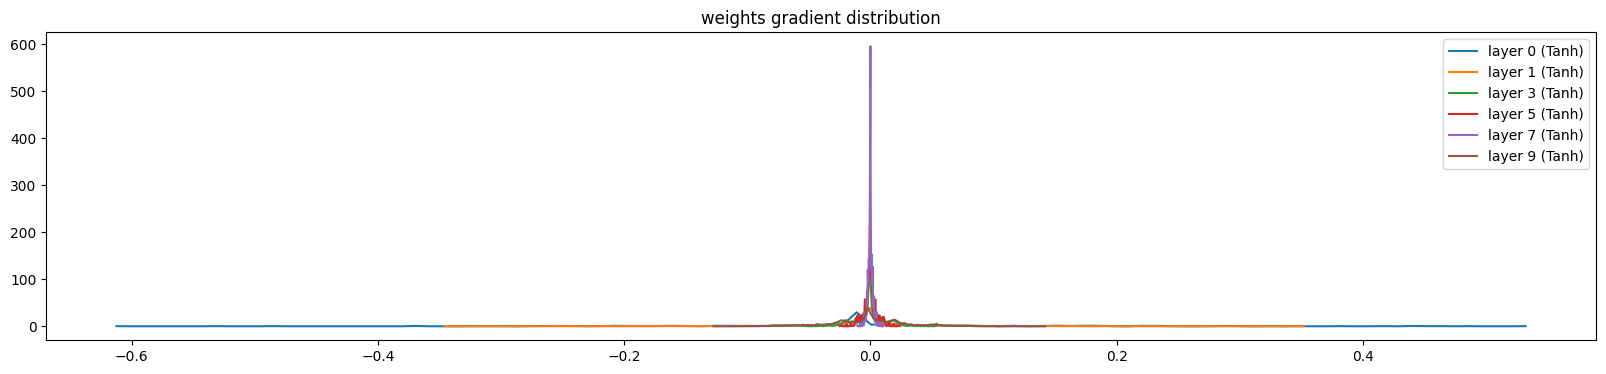

In [52]:
# at i= 1000

plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


layer 1 (      Tanh): mean -0.000214, std: 4.194560e-02
layer 3 (      Tanh): mean -0.000268, std: 1.636092e-02
layer 5 (      Tanh): mean -0.000262, std: 6.215760e-03
layer 7 (      Tanh): mean +0.000050, std: 1.994715e-03


Text(0.5, 1.0, 'gradient distribution')

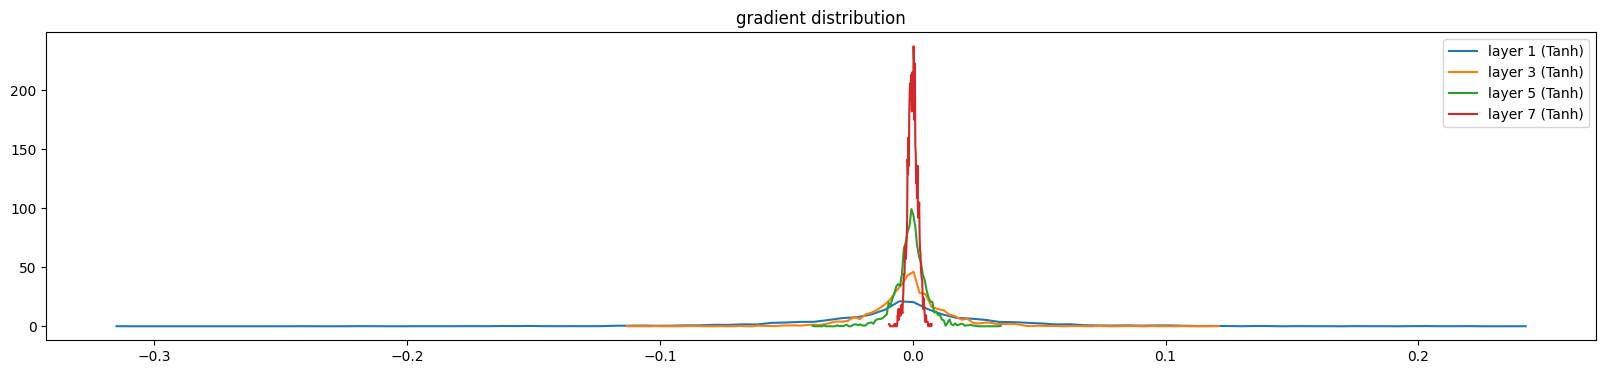

In [53]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 1 (      Tanh): mean +0.01, std: 0.99, saturated: 93.66
layer 3 (      Tanh): mean -0.02, std: 0.98, saturated: 90.62
layer 5 (      Tanh): mean +0.01, std: 0.98, saturated: 91.22
layer 7 (      Tanh): mean -0.03, std: 0.98, saturated: 89.72


Text(0.5, 1.0, 'activation distribution')

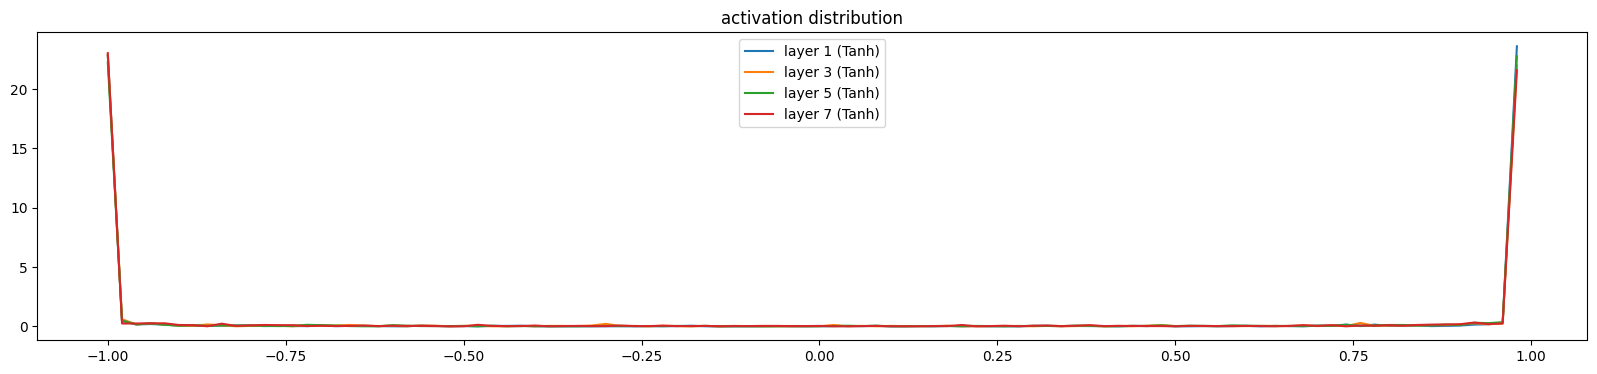

In [54]:
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

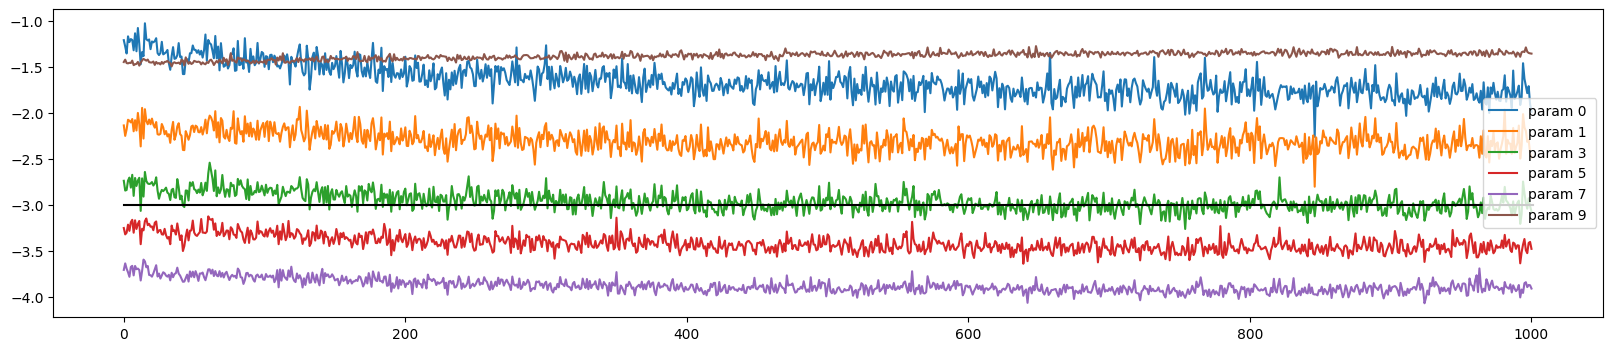

In [ ]:
#when lr = 0.1
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

###### with BN Plots

weight   (27, 10) | mean -0.000000 | std +6.551304e-03 | grad:data ratio 5.884385e-03
weight  (30, 100) | mean -0.000007 | std +2.260761e-03 | grad:data ratio 2.221723e-03
weight (100, 100) | mean +0.000008 | std +1.146541e-03 | grad:data ratio 1.141871e-03
weight (100, 100) | mean +0.000013 | std +1.030207e-03 | grad:data ratio 1.031786e-03
weight (100, 100) | mean -0.000004 | std +9.456223e-04 | grad:data ratio 9.494352e-04
weight  (100, 27) | mean -0.000001 | std +1.957496e-03 | grad:data ratio 1.925731e-03


Text(0.5, 1.0, 'weights gradient distribution')

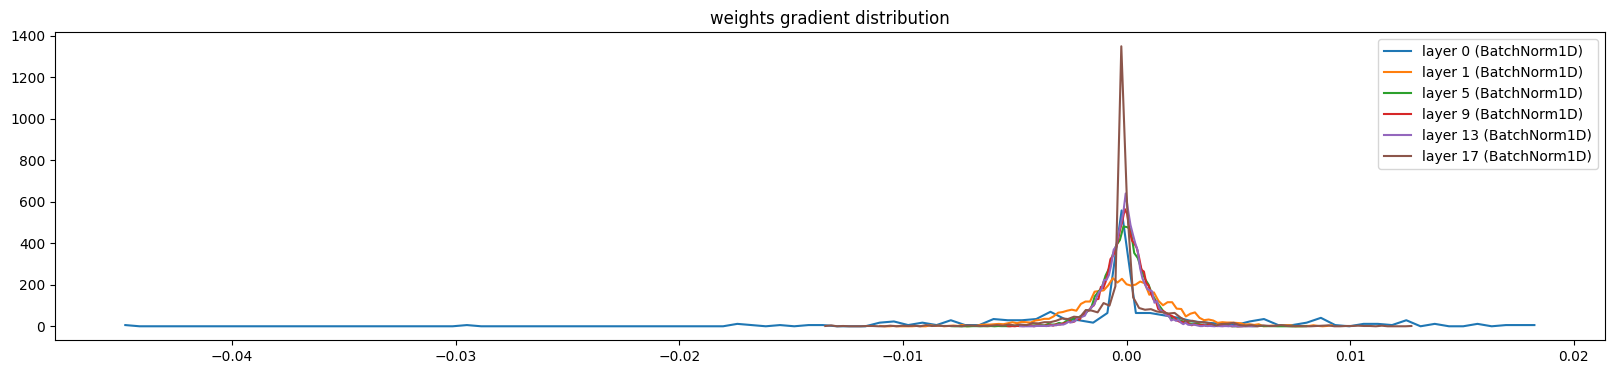

In [123]:
# at i= 1000

plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


layer 2 (      Tanh): mean +0.000000, std: 3.261254e-03
layer 5 (      Tanh): mean +0.000000, std: 2.896680e-03
layer 8 (      Tanh): mean -0.000000, std: 2.750749e-03
layer 11 (      Tanh): mean +0.000000, std: 2.742076e-03


Text(0.5, 1.0, 'gradient distribution')

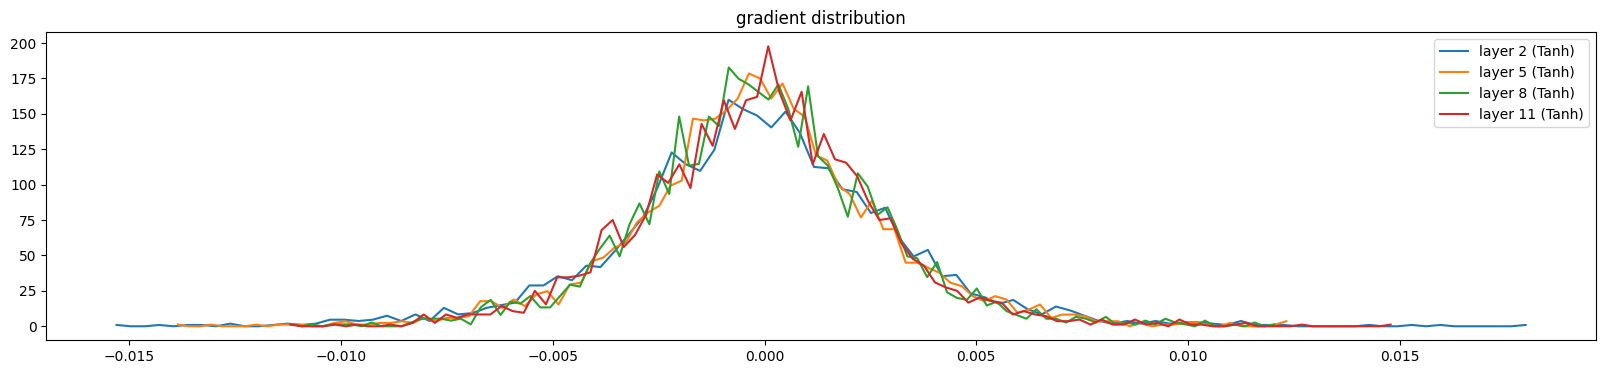

In [124]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

layer 2 (      Tanh): mean -0.00, std: 0.65, saturated: 5.53
layer 5 (      Tanh): mean -0.00, std: 0.65, saturated: 5.50
layer 8 (      Tanh): mean -0.00, std: 0.66, saturated: 5.94
layer 11 (      Tanh): mean +0.02, std: 0.65, saturated: 5.53


Text(0.5, 1.0, 'activation distribution')

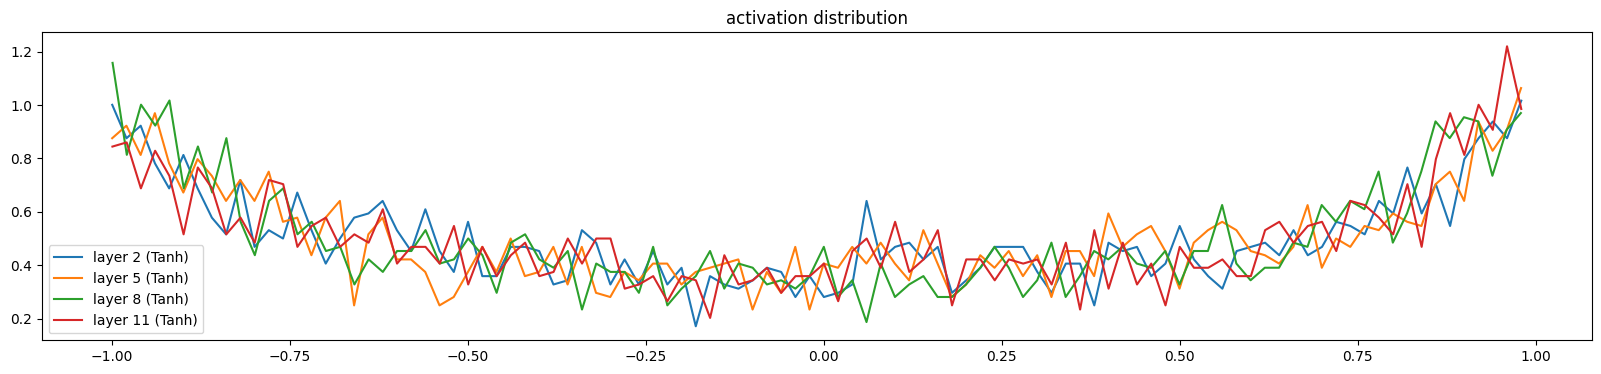

In [125]:
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

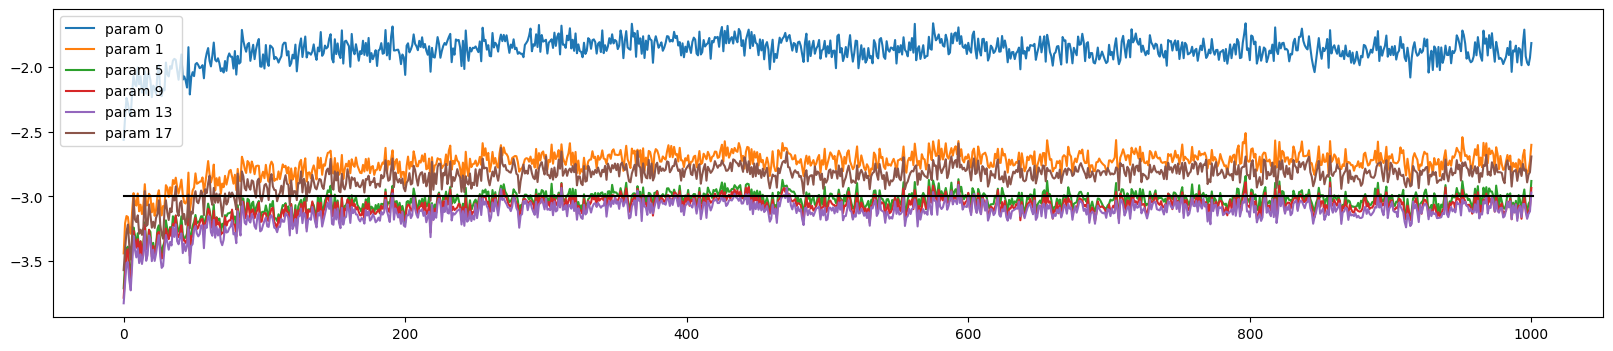

In [ ]:
#when lr = 2
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

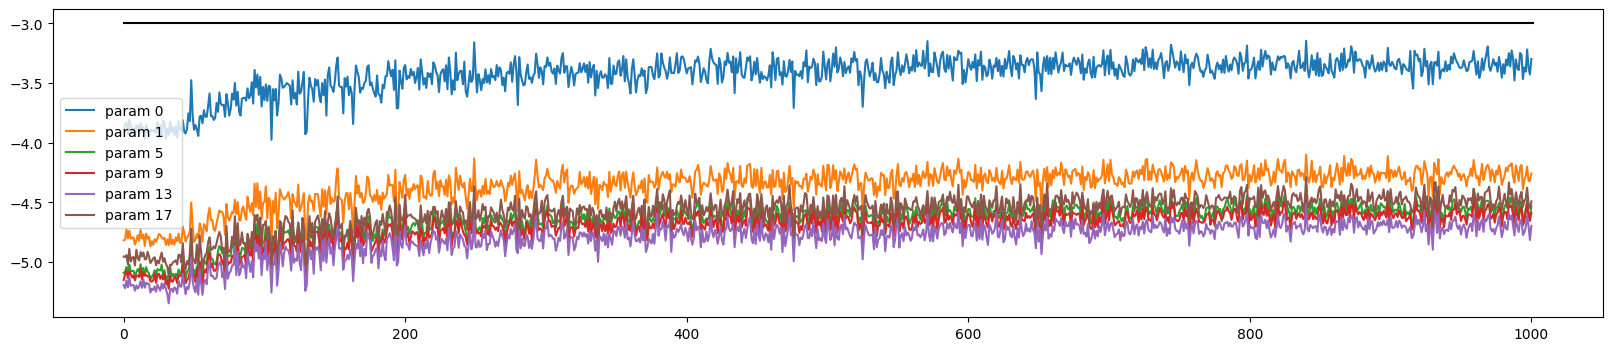

In [ ]:
#when lr = 0.1(slow training)
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

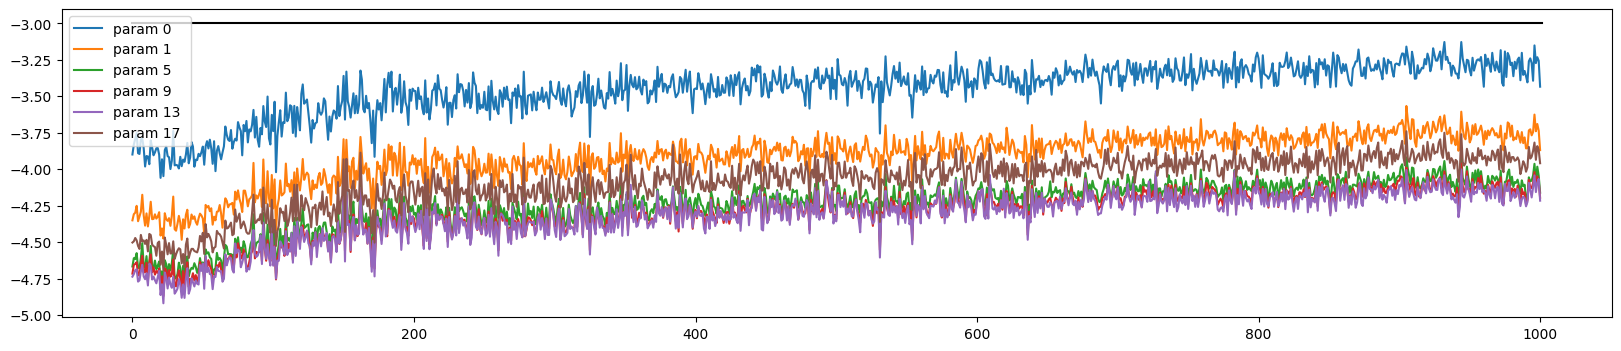

In [ ]:
#when lr = 0.1 and gain = 11
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

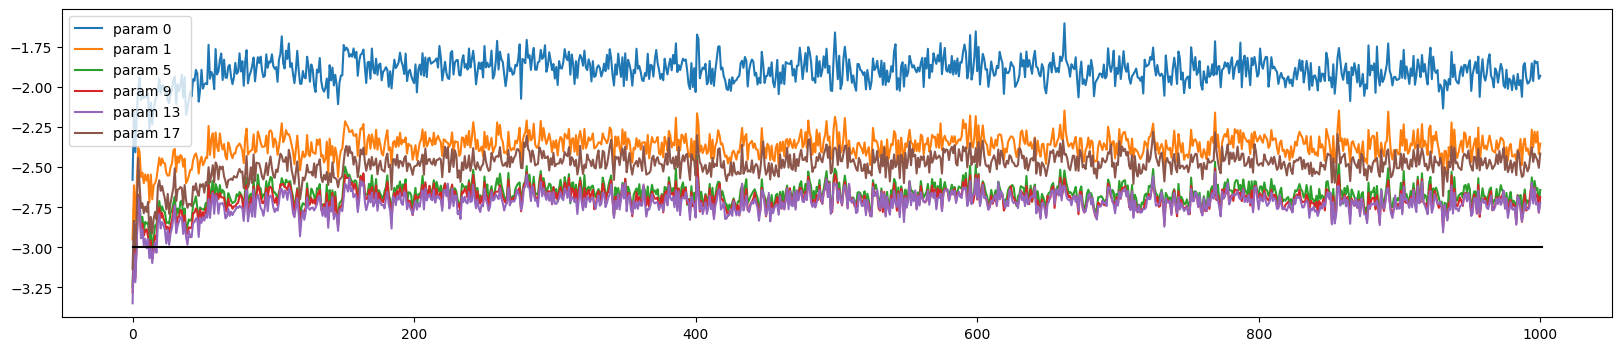

In [ ]:
#when lr = 2 and gain = 1
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

So, Just by tweaking learning rate we can achieve good things we neednot that much consider other constant like gain and stuff which was given by the conecpt of kaiming init... This all is possible because we started using BN. the 3 diagnostic plot
1. activation plot
2. gradient plot
3. weight to gradient update
all these 3 remain well behaved
4. update to data ratio is wjhat is crtitical and we should focus on.
and can be somehow improved by learning rate.

In [132]:
loss

tensor(1125.1910, grad_fn=<NllLossBackward0>)

### Training Properly

In [68]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out 
        self.isbias = bias
        self.bias = torch.zeros(fan_out) if bias else None
        self.weights = torch.randn(fan_in, fan_out)  /fan_in**0.5
        self.out = None

    def __call__(self, x):
        # print(x.dtype)
        # print(self.weights.dtype)
        self.out = x @ self.weights
        # print(self.bias)
        return self.out + self.bias if self.isbias else self.out

    def parameters(self):
        return [self.weights] + ([self.bias] if self.isbias is not None else [])
    

class BatchNorm1D:
    def __init__(self, dim,epsilon = 1e-5, momentum =0.1):
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)  
        self.running_std = torch.ones(dim)
        self.eps = epsilon
        self.momentum = momentum

    def __call__(self, x):
        if self.training:
            x_mean  = x.mean(0, keepdim = True)
            x_std = x.var(0, keepdim = True )
        else:
            x_mean = self.running_mean
            x_std = self.running_std

        self.out = self.gamma * ((x - x_mean)/torch.sqrt(x_std+ self.eps)) + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean  = self.momentum*x_mean  + (1- self.momentum)*self.running_mean
                self.running_std  = self.momentum*x_std  + (1- self.momentum)*self.running_std
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [89]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
n_embd = 10
hidden_dim = 100
g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd), generator = g)
t = Tanh()
layers =[
    Linear(n_embd*block_size, hidden_dim), BatchNorm1D(hidden_dim),Tanh(),
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim),Tanh(),   
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim), Tanh(),   
    Linear(hidden_dim, hidden_dim),BatchNorm1D(hidden_dim), Tanh(),   
    Linear(hidden_dim, vocab_size),BatchNorm1D(vocab_size)
]

with torch.no_grad():
    # layers[-1].weights *= 0.1
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  5/3#1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

37251


In [90]:
lre = torch.linspace(-3, 1,50001)
lrs = 10**lre
lrs


tensor([1.0000e-03, 1.0002e-03, 1.0004e-03,  ..., 9.9963e+00, 9.9982e+00,
        1.0000e+01])

In [91]:
import torch.nn.functional as F
max_steps = 50001
batch_size = 32
lossi= []
lri = []
ud = []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.5623413251903491
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])
    lossilog.append(loss.log10().item())
    lri.append(lre[i])

    
    if i == 50000:
        break

0 3.2673823833465576
5000 2.178748846054077
10000 2.1246516704559326
15000 2.49267315864563
20000 2.2638182640075684
25000 2.2894203662872314
30000 2.3443281650543213
35000 2.1951217651367188
40000 2.0861668586730957
45000 2.624201536178589
50000 2.1088173389434814


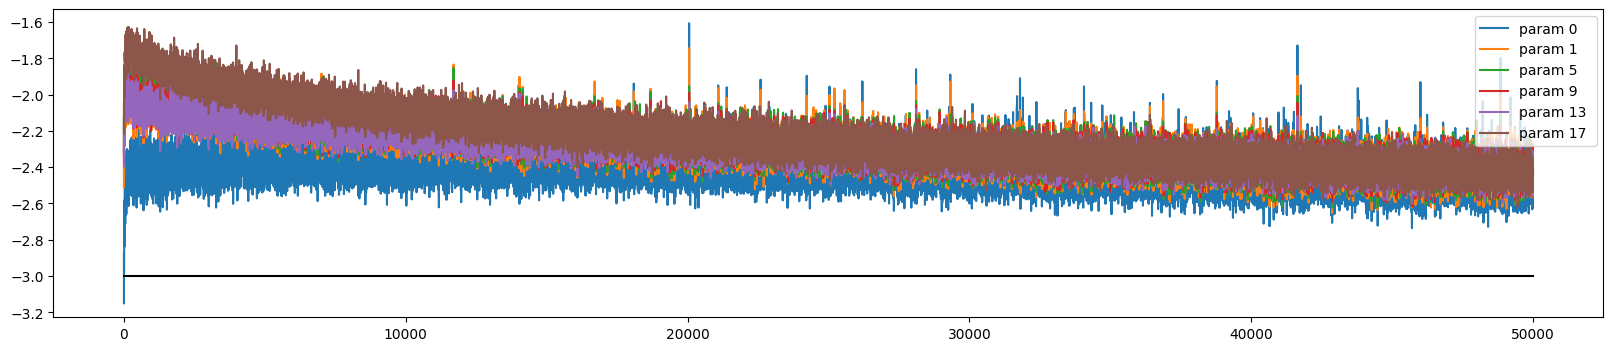

In [92]:
#when lr = 2 and gain = 1
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

In [88]:
10**-0.25

0.5623413251903491

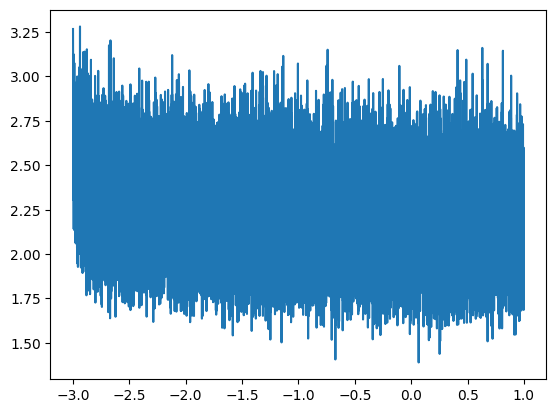

In [93]:
plt.plot(lri, lossi)

layer 2 (      Tanh): mean +0.00, std: 0.75, saturated: 25.75
layer 5 (      Tanh): mean +0.01, std: 0.80, saturated: 30.00
layer 8 (      Tanh): mean -0.03, std: 0.83, saturated: 32.38
layer 11 (      Tanh): mean -0.03, std: 0.84, saturated: 35.84


Text(0.5, 1.0, 'activation distribution')

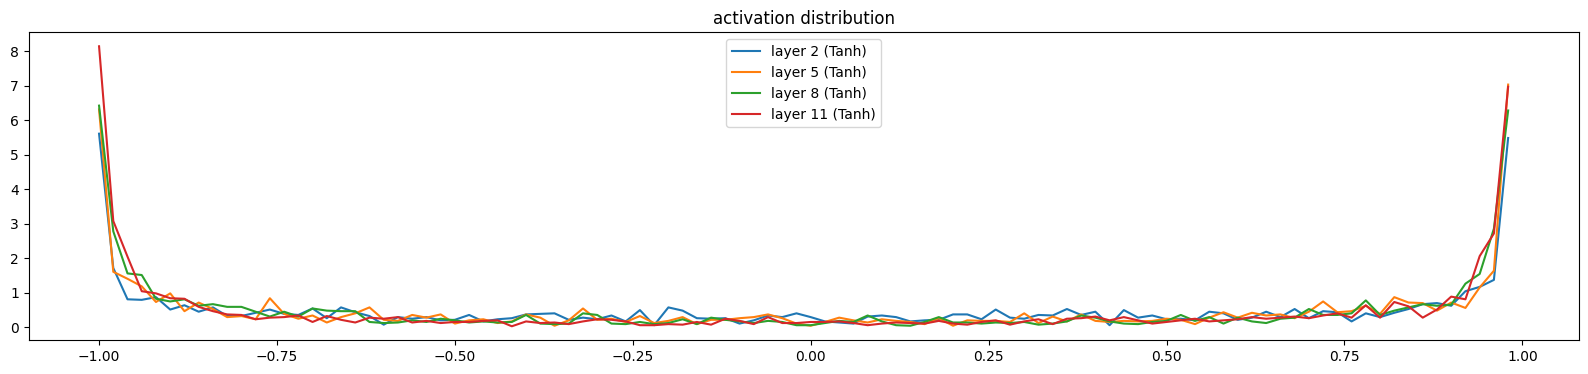

In [94]:
plt.figure(figsize= (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std: %.2f, saturated: %.2f' %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std: 2.920139e-03
layer 5 (      Tanh): mean -0.000000, std: 2.660519e-03
layer 8 (      Tanh): mean -0.000000, std: 2.522070e-03
layer 11 (      Tanh): mean +0.000000, std: 2.928937e-03


Text(0.5, 1.0, 'gradient distribution')

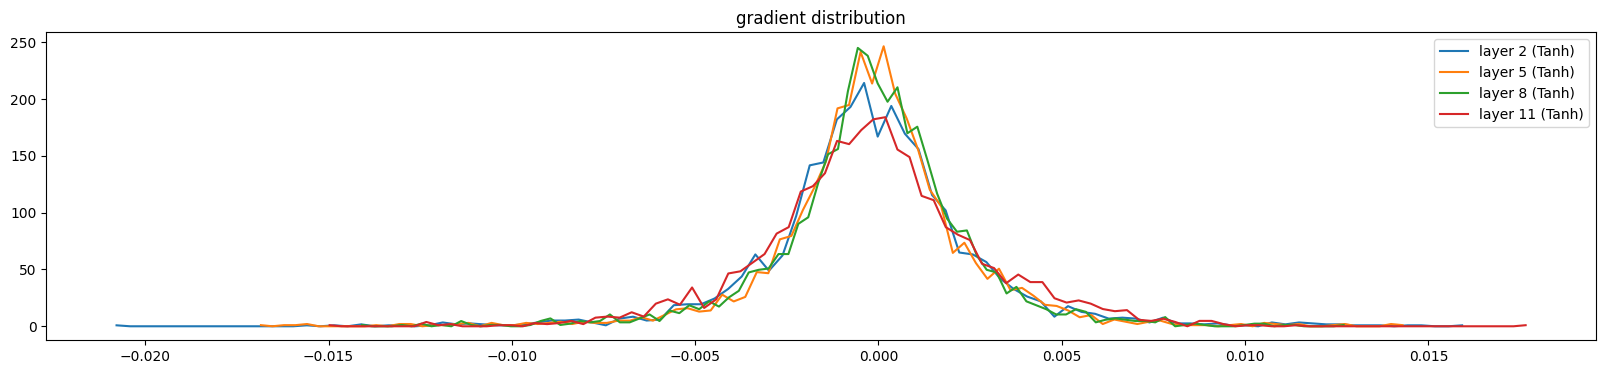

In [95]:
#with no tanh and gain = 5/3
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        g = layer.out.grad
        print('layer %d (%10s): mean %+f, std: %e' %(i, layer.__class__.__name__, g.mean(), g.std()))
        hy, hx = torch.histogram(g, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std +1.054193e-02 | grad:data ratio 6.818634e-03
weight  (30, 100) | mean +0.000028 | std +4.883387e-03 | grad:data ratio 7.335261e-03
weight (100, 100) | mean -0.000035 | std +2.595086e-03 | grad:data ratio 6.684116e-03
weight (100, 100) | mean +0.000039 | std +2.522542e-03 | grad:data ratio 6.814278e-03
weight (100, 100) | mean -0.000014 | std +2.232702e-03 | grad:data ratio 6.405341e-03
weight  (100, 27) | mean -0.000087 | std +4.066494e-03 | grad:data ratio 7.060347e-03


Text(0.5, 1.0, 'weights gradient distribution')

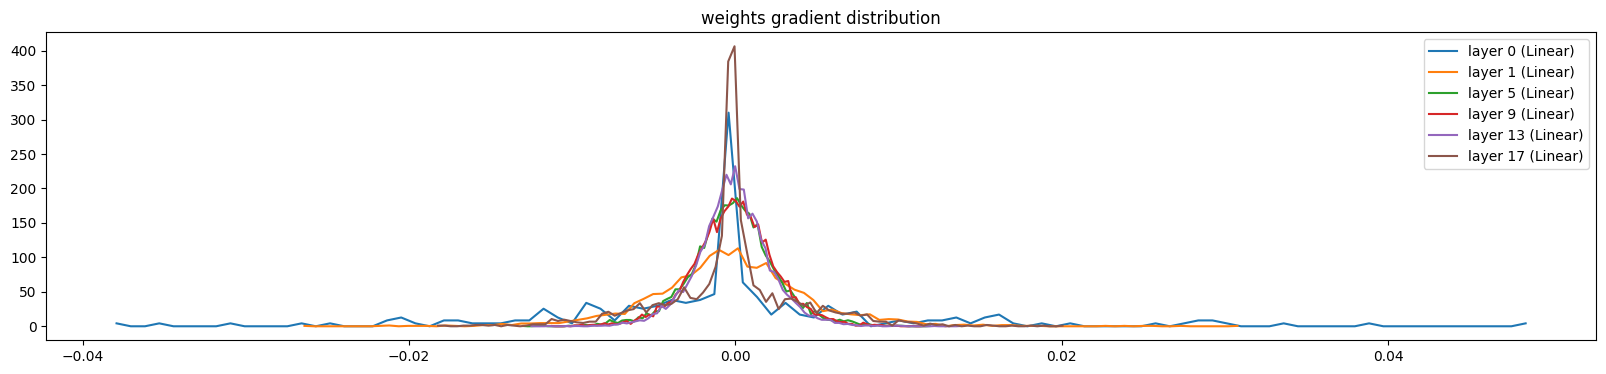

In [96]:
# at i= 1000

plt.figure(figsize = (20,4))
legends =[]
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(t.shape)
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %+e | grad:data ratio %e' %(tuple(p.shape), t.mean(), t.std(), t.std()/ p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('weights gradient distribution')


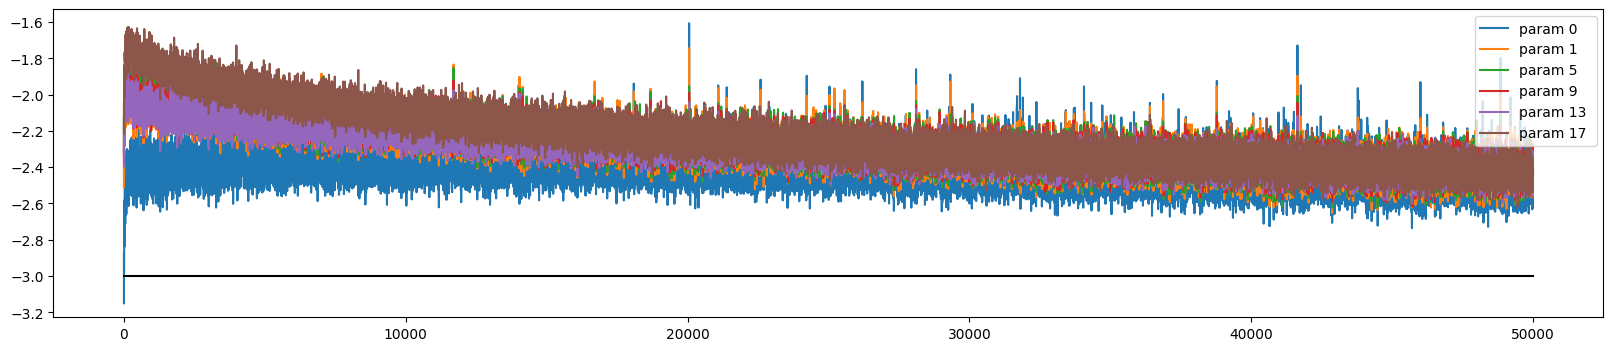

In [97]:
#when lr = 2 and gain = 1
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d '% i)

plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    x = C[x]
    x = x.view(x.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print (loss)

split_loss('train')
split_loss('val')